# DSC 288 Capstone — Google Analytics Session Revenue Prediction

**Course:** DSC 288R Capstone  
**Team:** Justin Chanthabandith · Pooja Panchal · Jinxin Xiao  
**Dataset:** Google Analytics Customer Revenue Prediction (Kaggle)

---

This notebook covers the full Milestone 4 pipeline:

1. **Background** — problem motivation and business importance  
2. **Literature Survey** — prior work, common approaches, and gaps addressed  
3. **Why Machine Learning** — justification for the ML approach  
4. **Dataset Details** — source, structure, and key challenges  
5. **Data Pipeline** — loading, JSON extraction, and cleaning workflow  
6. **EDA** — univariate, categorical, time-based, multivariate analysis, and EDA-driven feature selection  
7. **Feature Engineering** — leakage-safe visitor history, preprocessing, and train/test split  
8. **Modeling** — baselines, Random Forest, XGBoost, LightGBM, and feature importance  
9. **Results and Observations** — full RMSE/MAE table, discussion, and model interpretation  
10. **Conclusion** — key findings, practical implications, and future work
11. **Team Contributions**  
12. **References**


---
## 1. Background

### Problem Statement

The goal of this project is to predict **session-level customer revenue** using the Google Analytics Customer Revenue Prediction dataset from Kaggle. Specifically, the project attempts to:

- predict **whether** a website session will generate any revenue (classification), and  
- estimate the **amount** of revenue for sessions that do generate revenue (regression).

The primary evaluation metric is **RMSE on log-transformed revenue**, which is standard for this competition and dataset.

### Why This Problem Matters

E-commerce companies spend heavily on advertising and customer acquisition through paid search, organic search, social media, referrals, and direct traffic. However, most website sessions produce no revenue — a small fraction of visitors generate the vast majority of sales.

Accurate revenue prediction can help businesses:

- improve advertising efficiency and reduce wasted spend,  
- identify and target high-value users,  
- personalize marketing campaigns and landing experiences,  
- and increase return on investment.

This is also a realistic and challenging machine learning problem because it involves large-scale structured data, very sparse positive labels, high-cardinality categorical features, missing values, and risks of data leakage from visitor-level aggregation.


---
## 2. Literature Survey

### Traditional Approaches

Traditional customer revenue prediction relies on rule-based marketing analytics, customer segmentation, summary statistics, and simple statistical models such as linear regression for revenue and logistic regression for purchase classification. These methods are interpretable and easy to deploy, but they often fail to capture nonlinear customer behavior, sparse purchase events, and complex interactions among traffic source, device type, geography, and session behavior.

### Modern Machine Learning Approaches

More recent work uses tree-based models (Random Forest, XGBoost, LightGBM, CatBoost) and neural networks. These are better suited for structured e-commerce data because they capture nonlinear relationships and feature interactions without requiring manual feature crosses. Top Kaggle solutions for this competition commonly use:

- visitor-level historical features (prior session count, prior total revenue, purchase rate),  
- session behavior features (hits, pageviews, visit number, bounces),  
- traffic source and channel features,  
- log-transformed revenue targets to handle skew,  
- and `fullVisitorId`-based train/test splits to prevent visitor leakage.

### Gaps Addressed by This Project

Common issues in prior revenue prediction work include:

- feature leakage from visitor-level aggregation that includes the current session's revenue,  
- improper random splitting that allows the same visitor to appear in both train and test sets,  
- and memory bottlenecks when processing large nested JSON datasets.

This project addresses those gaps by using Polars for scalable preprocessing, computing leakage-safe cumulative visitor features using only prior sessions, applying `fullVisitorId`-based splitting, and explicitly comparing baseline models against machine learning models.


---
## 3. Why Machine Learning Can Help

Customer revenue prediction is not a purely linear problem. Whether a user purchases depends
on many interacting factors — traffic source, device, geography, visit timing, prior behavior —
none of which has a simple additive effect in isolation.

Machine learning is well-suited here because it can model nonlinear patterns and feature
interactions that traditional regression misses. Tree-based ensemble models in particular:

- handle nonlinear relationships between features and revenue,
- capture interaction effects across device, channel, and behavior features,
- are robust to outliers and skewed distributions,
- work well with mixed numeric and categorical features,
- and scale effectively to large structured datasets.

The central hypothesis is that ML models should outperform naive baselines by learning
useful patterns from the combined feature set, and that gradient boosting models
(XGBoost, LightGBM) should further outperform vanilla Random Forest through iterative
residual correction and built-in regularization.


---
## 4. Dataset Details

### Source and Citation

**Dataset:** Google Analytics Customer Revenue Prediction  
**Source:** Kaggle Competition  
**Link:** https://www.kaggle.com/c/ga-customer-revenue-prediction  
**File used:** `train_v2.csv`

The dataset contains anonymized, session-level Google Analytics data from the Google Merchandise Store.

### Dataset Description

Each row represents one website session and includes:

| Field Group | Examples |
|---|---|
| Visitor identity | `fullVisitorId` |
| Session timing | `date`, `visitStartTime`, `visitNumber` |
| Traffic | `channelGrouping`, `trafficSource.medium`, `trafficSource.source` |
| Device | `device.deviceCategory`, `device.browser`, `device.operatingSystem` |
| Geography | `geoNetwork.country` |
| Session activity | `totals.hits`, `totals.pageviews`, `totals.bounces`, `totals.newVisits` |
| Revenue | `totals.transactionRevenue` (target) |

The raw data stores device, network, totals, and traffic source as nested JSON strings. These were extracted using Polars regex-based extraction for efficiency.

### Dataset Challenges

- **Zero inflation:** the vast majority of sessions have zero revenue.  
- **Skewed positives:** positive revenue values span several orders of magnitude.  
- **High-cardinality categoricals:** `country`, `browser`, and `source` have many unique values.  
- **Missing values:** several fields have substantial missingness, often non-random.  
- **Visitor leakage risk:** the same `fullVisitorId` can appear across many sessions; naive aggregation leaks future revenue into training features.


---
## 5. Data Pipeline

### 5.1 Environment Setup

Run the install cell once per fresh DataHub session. Restart the kernel after installation to avoid import issues.


In [1]:
%pip install -q "kaggle>=1.8.0" pandas polars pyarrow scikit-learn matplotlib xgboost lightgbm

Note: you may need to restart the kernel to use updated packages.


### 5.2 Kaggle Authentication

The cell below configures the Kaggle API token. Replace the placeholder with your own token before running.


In [2]:

import os
from pathlib import Path
from getpass import getpass

token = "KGAT_1b9be33806319e3512562491581b274d"  # Replace with your own token

if not token:
    raise ValueError("No token was provided.")

os.environ["KAGGLE_API_TOKEN"] = token

os.makedirs(".kaggle", exist_ok=True)
with open(".kaggle/access_token", "w") as f:
    f.write(token)

os.chmod(".kaggle/access_token", 0o600)
os.environ["KAGGLE_CONFIG_DIR"] = os.path.abspath(".kaggle")

print("Kaggle token configured.")
print("KAGGLE_CONFIG_DIR =", os.environ["KAGGLE_CONFIG_DIR"])

Kaggle token configured.
KAGGLE_CONFIG_DIR = /home/j1chanthabandith/private/DSC_288R/Milestone 4/.kaggle


### 5.3 Download and Extract Data


In [3]:

import os
import zipfile
from pathlib import Path
from kaggle.api.kaggle_api_extended import KaggleApi

api = KaggleApi()
api.authenticate()

zip_path = Path("ga-customer-revenue-prediction.zip")

if not zip_path.exists():
    api.competition_download_files(
        "ga-customer-revenue-prediction",
        path="."
    )
    print("Download finished.")
else:
    print("Zip already exists, skipping download.")

print("Current files:")
print(sorted(os.listdir("."))[:25])

Zip already exists, skipping download.
Current files:
['.ipynb_checkpoints', '.kaggle', 'Final_Report_fixed.ipynb', 'Milestone_4.ipynb', 'Milestone_4_polished (1).ipynb', 'Milestone_4_polished.ipynb', 'fig_boxplot_log_revenue.png', 'fig_boxplot_revenue.png', 'fig_boxplot_totals_hits.png', 'fig_boxplot_totals_pageviews.png', 'fig_correlation_heatmap.png', 'fig_dow_revenue_rate.png', 'fig_hourly_revenue_rate.png', 'fig_log_revenue_dist.png', 'fig_monthly_revenue_rate.png', 'fig_positive_log_revenue_dist.png', 'fig_revenue_rate_channelGrouping.png', 'fig_revenue_rate_device_deviceCategory.png', 'fig_revenue_rate_geoNetwork_country.png', 'fig_revenue_rate_trafficSource_medium.png', 'fig_scatter_totals_hits_vs_log_revenue.png', 'fig_scatter_totals_pageviews_vs_log_revenue.png', 'fig_scatter_visitNumber_vs_log_revenue.png', 'fig_totals_hits_hist.png', 'fig_totals_pageviews_hist.png']


In [4]:

import zipfile
from pathlib import Path

zip_path = Path("ga-customer-revenue-prediction.zip")

if not zip_path.exists():
    raise FileNotFoundError("ga-customer-revenue-prediction.zip was not created.")

with zipfile.ZipFile(zip_path, "r") as z:
    names = z.namelist()
    print("Files inside zip:", names)
    if "train_v2.csv" in names:
        z.extract("train_v2.csv", ".")
    else:
        z.extractall(".")

print("Extraction complete.")
print("train_v2.csv exists:", Path("train_v2.csv").exists())

Files inside zip: ['sample_submission.csv', 'sample_submission_v2.csv', 'test.csv', 'test_v2.csv', 'train.csv', 'train_v2.csv']
Extraction complete.
train_v2.csv exists: True


### 5.4 Imports and Helper Functions


In [5]:
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt

from pandas import json_normalize

from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor

import xgboost as xgb
import lightgbm as lgb

pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

### 5.5 Data Loading with Polars

To avoid kernel crashes on the large CSV, the notebook uses **Polars** for the initial load. Only the nested JSON fields needed for EDA and modeling are extracted — raw JSON columns are dropped immediately after extraction. The result is then converted to pandas for EDA code.

**Key design decisions:**
- Avoid `pd.read_csv(..., converters=...)` on all rows.
- Avoid `json_normalize` on every JSON column for all rows.
- Use Polars string extraction for selected fields only.
- Convert to pandas only after reducing the column count.


In [6]:

DATA_PATH = "train_v2.csv"

if not Path(DATA_PATH).exists():
    raise FileNotFoundError("train_v2.csv not found. Run the download/extract cells first.")

# Only keep the columns needed for EDA/modeling. This makes the full dataset much safer to load.
BASE_COLUMNS = [
    "fullVisitorId",
    "date",
    "visitStartTime",
    "visitNumber",
    "channelGrouping",
    "device",
    "geoNetwork",
    "totals",
    "trafficSource",
]

# These are the nested JSON fields used later in the notebook.
JSON_FIELD_MAP = {
    "totals": ["transactionRevenue", "hits", "pageviews", "bounces", "newVisits"],
    "device": ["deviceCategory", "browser", "operatingSystem"],
    "geoNetwork": ["country"],
    "trafficSource": ["medium", "source"],
}

def extract_json_value_expr(json_col: str, key: str) -> pl.Expr:
    """Extract one simple key from a JSON-like string column without fully flattening the JSON."""
    pattern = rf'"{key}"\s*:\s*"?([^",}}]*)"?'
    return pl.col(json_col).str.extract(pattern, 1)

def load_ga_data_full_polars(path: str) -> pl.DataFrame:
    """Load all rows safely with Polars and extract only the JSON fields needed for this notebook."""
    data = pl.read_csv(
        path,
        columns=BASE_COLUMNS,
        schema_overrides={
            "fullVisitorId": pl.Utf8,
            "date": pl.Utf8,
        },
        ignore_errors=True,
    )

    extract_exprs = []
    for json_col, keys in JSON_FIELD_MAP.items():
        for key in keys:
            extract_exprs.append(
                extract_json_value_expr(json_col, key).alias(f"{json_col}.{key}")
            )

    data = data.with_columns(extract_exprs)

    # Drop raw JSON columns after extracting the needed fields to reduce memory usage.
    data = data.drop([col for col in JSON_FIELD_MAP.keys() if col in data.columns])

    return data

# Full dataset, all rows, but only selected useful columns.
pl_df_full = load_ga_data_full_polars(DATA_PATH)
print("Polars full shape:", pl_df_full.shape)

# Convert to pandas for the existing EDA code below.
# This is much safer now because the raw JSON columns were removed and only selected fields remain.
df = pl_df_full.to_pandas()
print("Pandas reduced full shape:", df.shape)
df.head()


Polars full shape: (1708337, 16)
Pandas reduced full shape: (1708337, 16)


,channelGrouping,date,fullVisitorId,visitNumber,visitStartTime,totals.transactionRevenue,totals.hits,totals.pageviews,totals.bounces,totals.newVisits,device.deviceCategory,device.browser,device.operatingSystem,geoNetwork.country,trafficSource.medium,trafficSource.source
0,Organic Search,20171016,3162355547410993243,1,1508198450,None,1,1,1,1,desktop,Firefox,Windows,Germany,organic,google
1,Referral,20171016,8934116514970143966,6,1508176307,None,2,2,None,None,desktop,Chrome,Chrome OS,United States,referral,sites.google.com
2,Direct,20171016,7992466427990357681,1,1508201613,None,2,2,None,1,mobile,Chrome,Android,United States,(none),(direct)
3,Organic Search,20171016,9075655783635761930,1,1508169851,None,2,2,None,1,desktop,Chrome,Windows,Turkey,organic,google
4,Organic Search,20171016,6960673291025684308,1,1508190552,None,2,2,None,1,desktop,Chrome,Windows,Mexico,organic,google


### 5.6 Pipeline Summary

The full pipeline processes the raw nested data into a clean, model-ready table through these steps:

1. Download and extract `train_v2.csv` from Kaggle.
2. Load with Polars, extracting only required nested JSON fields.
3. Convert numeric revenue to float; engineer `revenue`, `has_revenue`, `log_revenue`.
4. Parse `date` and `visitStartTime` into date/time features (year, month, day of week, hour).
5. Inspect missing values, low-variance columns, duplicates, and outliers.
6. Compute leakage-safe visitor-level cumulative features (Section 7).
7. Encode categoricals, reduce high-cardinality features, apply median imputation.
8. Split train/test by `fullVisitorId` to prevent visitor overlap.


---
## 6. Exploratory Data Analysis (EDA)

EDA is organized as follows:

- **6.1** Basic structure and data types  
- **6.2** Target engineering (revenue, has_revenue, log_revenue)  
- **6.3** Zero inflation and skew  
- **6.4** Missing value analysis  
- **6.5** Low-variance / near-constant columns  
- **6.6** Numeric behavior features (hits, pageviews, visitNumber)  
- **6.7** Categorical feature analysis (device, channel, traffic source, geography)  
- **6.8** Time-based analysis (monthly, day-of-week, hourly patterns)  
- **6.9** Visitor-level aggregation  
- **6.10** Data health check summary  
- **6.11** Outlier analysis  
- **6.12** Multivariate analysis and correlation heatmap  
- **6.13** EDA summary, feature selection decisions, and modeling hypotheses  

### 6.1 Basic Structure Overview


In [7]:

overview = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
    "n_unique": df.nunique(dropna=False)
}).sort_values(["missing_pct", "n_unique"], ascending=[False, True])

overview.head(30)

,dtype,missing_count,missing_pct,n_unique
totals.transactionRevenue,object,1689823,98.9200,7252
totals.bounces,object,836759,48.9800,2
totals.newVisits,object,400907,23.4700,2
totals.pageviews,object,239,0.0100,231
device.deviceCategory,object,0,0.0000,3
trafficSource.medium,object,0,0.0000,7
channelGrouping,object,0,0.0000,8
device.operatingSystem,object,0,0.0000,24
device.browser,object,0,0.0000,129
geoNetwork.country,object,0,0.0000,228


### 6.2 Target Engineering

The main target is `totals.transactionRevenue`. Three derived fields are created:
- `revenue` — numeric transaction revenue (0 for missing).
- `has_revenue` — binary indicator (1 if session produced any revenue).
- `log_revenue` — log1p-transformed revenue, the actual regression target.

Time-based features (year, month, day of week, hour) are also parsed here.


In [8]:

df["revenue"] = pd.to_numeric(df.get("totals.transactionRevenue"), errors="coerce").fillna(0)
df["has_revenue"] = (df["revenue"] > 0).astype(int)
df["log_revenue"] = np.log1p(df["revenue"])

df["date"] = df["date"].astype(str)
df["date_parsed"] = pd.to_datetime(df["date"], format="%Y%m%d", errors="coerce")
df["visit_start_dt"] = pd.to_datetime(df["visitStartTime"], unit="s", errors="coerce")

df["year"] = df["date_parsed"].dt.year
df["month"] = df["date_parsed"].dt.to_period("M").astype(str)
df["day_of_week"] = df["date_parsed"].dt.day_name()
df["hour"] = df["visit_start_dt"].dt.hour

for col in ["totals.hits", "totals.pageviews", "totals.bounces", "totals.newVisits", "visitNumber"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df[["fullVisitorId", "revenue", "has_revenue", "log_revenue", "date_parsed"]].head()

,fullVisitorId,revenue,has_revenue,log_revenue,date_parsed
0,3162355547410993243,0.0000,0,0.0000,2017-10-16
1,8934116514970143966,0.0000,0,0.0000,2017-10-16
2,7992466427990357681,0.0000,0,0.0000,2017-10-16
3,9075655783635761930,0.0000,0,0.0000,2017-10-16
4,6960673291025684308,0.0000,0,0.0000,2017-10-16


### 6.3 Zero Inflation and Skew

This is the most important structural property of the dataset. Most sessions generate no revenue at all, and positive revenue is strongly right-skewed. This directly motivates the two-step modeling approach (classify purchase vs. no-purchase first, then regress on positive cases).


In [9]:

target_summary = pd.Series({
    "total_sessions": len(df),
    "positive_revenue_sessions": int(df["has_revenue"].sum()),
    "zero_revenue_sessions": int((df["has_revenue"] == 0).sum()),
    "positive_rate_pct": round(df["has_revenue"].mean() * 100, 4),
    "mean_revenue": df["revenue"].mean(),
    "median_revenue": df["revenue"].median(),
    "max_revenue": df["revenue"].max()
})
target_summary.to_frame("value")

,value
total_sessions,"1,708,337.0000"
positive_revenue_sessions,"18,514.0000"
zero_revenue_sessions,"1,689,823.0000"
positive_rate_pct,1.0837
mean_revenue,"1,355,906.3463"
median_revenue,0.0000
max_revenue,"23,129,500,000.0000"


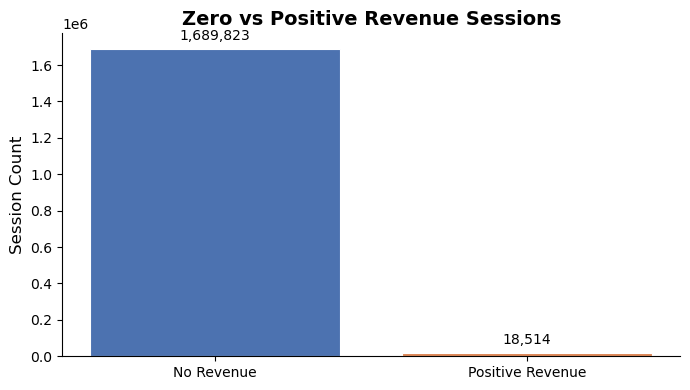

Saved: fig_zero_vs_positive_revenue.png


In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))
counts = df["has_revenue"].value_counts().sort_index()
bars = ax.bar(["No Revenue", "Positive Revenue"], counts.values,
              color=["#4C72B0", "#DD8452"], edgecolor="white", linewidth=0.8)
ax.set_ylabel("Session Count", fontsize=12)
ax.set_title("Zero vs Positive Revenue Sessions", fontsize=14, fontweight="bold")
ax.bar_label(bars, fmt="{:,.0f}", padding=4, fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("fig_zero_vs_positive_revenue.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig_zero_vs_positive_revenue.png")


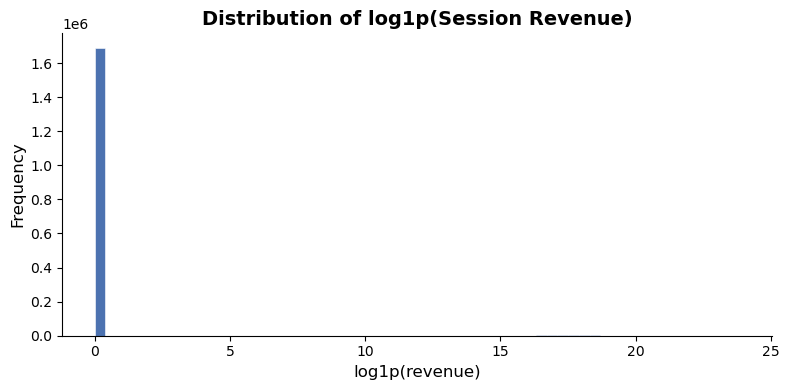

Saved: fig_log_revenue_dist.png


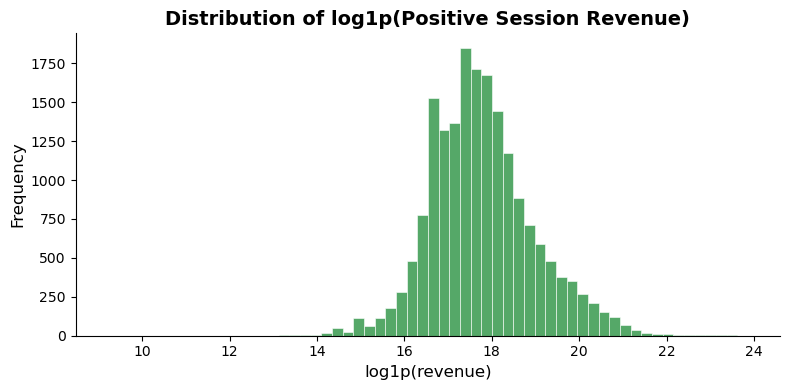

Saved: fig_positive_log_revenue_dist.png


In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
df["log_revenue"].plot(kind="hist", bins=60, ax=ax, color="#4C72B0", edgecolor="white", linewidth=0.4)
ax.set_title("Distribution of log1p(Session Revenue)", fontsize=14, fontweight="bold")
ax.set_xlabel("log1p(revenue)", fontsize=12)
ax.set_ylabel("Frequency", fontsize=12)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("fig_log_revenue_dist.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig_log_revenue_dist.png")

positive_rev = df.loc[df["revenue"] > 0, "revenue"]
if len(positive_rev) > 0:
    fig2, ax2 = plt.subplots(figsize=(8, 4))
    np.log1p(positive_rev).plot(kind="hist", bins=60, ax=ax2, color="#55A868", edgecolor="white", linewidth=0.4)
    ax2.set_title("Distribution of log1p(Positive Session Revenue)", fontsize=14, fontweight="bold")
    ax2.set_xlabel("log1p(revenue)", fontsize=12)
    ax2.set_ylabel("Frequency", fontsize=12)
    ax2.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.savefig("fig_positive_log_revenue_dist.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: fig_positive_log_revenue_dist.png")


### 6.4 Missing Value Analysis

Missingness in web analytics data is often non-random. Two columns deserve special attention here:

- **`totals.bounces`** — in the raw data this field is `"1"` when a user bounced and **null otherwise** (not truly missing — null means "did not bounce"). After numeric conversion and median imputation, the column collapses to a near-constant value and loses all variance.
- **`totals.newVisits`** — same pattern: `"1"` for a new visit, null for return visits. Imputation flattens it. The signal it carries is also largely redundant with `visitNumber` (if `visitNumber == 1`, it's almost always a new visit).

The correlation heatmap in Section 6.12 confirms this: both columns show near-zero correlation with everything, including each other — a clear sign that their variance has been destroyed by the extraction and imputation process. We will drop both from the modeling feature set and note this as an EDA-driven decision.


In [12]:

missing_df = (
    df.isna().mean()
      .mul(100)
      .round(2)
      .sort_values(ascending=False)
      .reset_index()
)
missing_df.columns = ["column", "missing_pct"]
missing_df.head(25)

,column,missing_pct
0,totals.transactionRevenue,98.9200
1,totals.bounces,48.9800
2,totals.newVisits,23.4700
3,totals.pageviews,0.0100
4,channelGrouping,0.0000
5,trafficSource.source,0.0000
6,day_of_week,0.0000
7,month,0.0000
8,year,0.0000
9,visit_start_dt,0.0000


### 6.5 Low-Variance / Near-Constant Columns

Columns with very few unique values add little information to a model and can introduce noise. These are identified here and dropped or ignored in the feature set.


In [13]:

nunique_df = pd.DataFrame({
    "column": df.columns,
    "n_unique": [df[col].nunique(dropna=False) for col in df.columns]
}).sort_values("n_unique")

nunique_df.head(30)

,column,n_unique
17,has_revenue,2
9,totals.newVisits,2
8,totals.bounces,2
21,year,3
10,device.deviceCategory,3
14,trafficSource.medium,7
23,day_of_week,7
0,channelGrouping,8
22,month,21
12,device.operatingSystem,24


### 6.6 Numeric Behavior Features

Session engagement variables — hits, pageviews, and visit number — are the core behavioral features. We include `totals.bounces` and `totals.newVisits` in this initial summary to inspect them, but as shown below and confirmed in the correlation heatmap (Section 6.12), both are structurally near-constant after extraction and median imputation. They will be **dropped from the final feature set**.


In [14]:

numeric_cols = [col for col in [
    "totals.hits", "totals.pageviews", "visitNumber",
    "totals.bounces", "totals.newVisits",
    "revenue", "log_revenue"
] if col in df.columns]

# Note: totals.bounces and totals.newVisits will show near-zero std — this is expected
# due to their binary/null structure collapsing under median imputation.
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
totals.hits,"1,708,337.0000",4.4296,8.9917,1.0000,1.0000,1.0000,4.0000,500.0000
totals.pageviews,"1,708,098.0000",3.6962,6.4732,1.0000,1.0000,1.0000,4.0000,500.0000
visitNumber,"1,708,337.0000",2.3352,9.3540,1.0000,1.0000,1.0000,1.0000,457.0000
totals.bounces,"871,578.0000",1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
totals.newVisits,"1,307,430.0000",1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
revenue,"1,708,337.0000","1,355,906.3463","45,228,085.0896",0.0000,0.0000,0.0000,0.0000,"23,129,500,000.0000"
log_revenue,"1,708,337.0000",0.1926,1.8441,0.0000,0.0000,0.0000,0.0000,23.8644


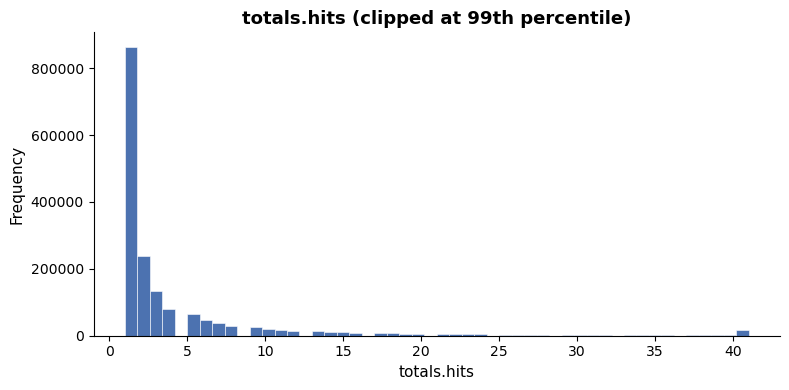

Saved: fig_totals_hits_hist.png


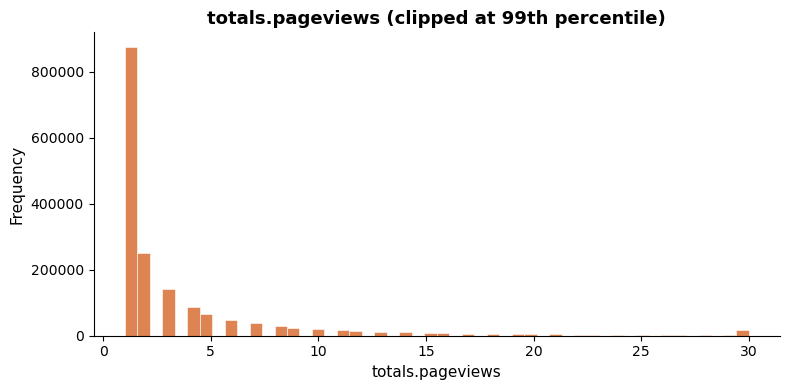

Saved: fig_totals_pageviews_hist.png


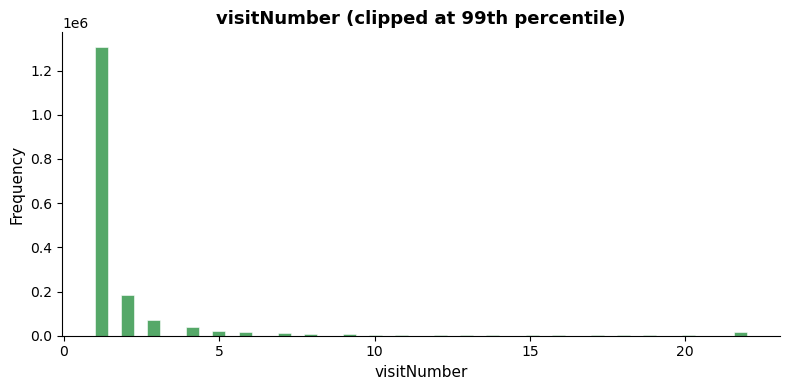

Saved: fig_visitNumber_hist.png


In [15]:
plot_cols = [col for col in ["totals.hits", "totals.pageviews", "visitNumber"] if col in df.columns]
palette = ["#4C72B0", "#DD8452", "#55A868"]

for i, col in enumerate(plot_cols):
    fig, ax = plt.subplots(figsize=(8, 4))
    df[col].dropna().clip(upper=df[col].quantile(0.99)).plot(
        kind="hist", bins=50, ax=ax,
        color=palette[i % len(palette)], edgecolor="white", linewidth=0.4)
    ax.set_title(f"{col} (clipped at 99th percentile)", fontsize=13, fontweight="bold")
    ax.set_xlabel(col, fontsize=11)
    ax.set_ylabel("Frequency", fontsize=11)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    fname = f"fig_{col.replace('.', '_')}_hist.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fname}")


In [16]:

behavior_cols = [col for col in ["totals.hits", "totals.pageviews", "visitNumber", "totals.bounces", "totals.newVisits"] if col in df.columns]

grouped_stats = {}
for col in behavior_cols:
    grouped_stats[col] = df.groupby("has_revenue")[col].mean()

behavior_compare = pd.DataFrame(grouped_stats).T
behavior_compare.columns = ["mean_if_no_revenue", "mean_if_positive_revenue"]
behavior_compare

# Observation: totals.bounces and totals.newVisits show little to no difference
# between revenue and non-revenue sessions — consistent with near-constant imputed values.
# These features will be excluded from the modeling pipeline.

,mean_if_no_revenue,mean_if_positive_revenue
totals.hits,4.0939,35.0662
totals.pageviews,3.4421,26.8839
visitNumber,2.3167,4.0231
totals.bounces,1.0000,NaN
totals.newVisits,1.0000,1.0000


### 6.7 Categorical Feature Analysis

The main categorical groups — traffic source, device, geography, and channel — are summarized by session count, positive revenue rate, and mean log revenue. Bar charts show which categories show higher purchase rates.


In [17]:

cat_cols = [
    "channelGrouping",
    "device.deviceCategory",
    "device.browser",
    "device.operatingSystem",
    "geoNetwork.country",
    "trafficSource.medium",
    "trafficSource.source"
]
cat_cols = [c for c in cat_cols if c in df.columns]

def top_category_summary(data, col, top_n=10):
    top_values = data[col].fillna("Missing").value_counts().head(top_n).index
    subset = data[data[col].fillna("Missing").isin(top_values)].copy()
    subset[col] = subset[col].fillna("Missing")

    summary = subset.groupby(col).agg(
        sessions=("fullVisitorId", "count"),
        positive_rate=("has_revenue", "mean"),
        mean_log_revenue=("log_revenue", "mean"),
        mean_revenue=("revenue", "mean")
    ).sort_values("sessions", ascending=False)

    summary["positive_rate"] = (summary["positive_rate"] * 100).round(3)
    return summary

for col in cat_cols:
    print(f"\n===== {col} =====")
    display(top_category_summary(df, col, top_n=10))


===== channelGrouping =====


,sessions,positive_rate,mean_log_revenue,mean_revenue
channelGrouping,,,,
Organic Search,738963,0.7460,0.1310,"730,075.7277"
Social,354971,0.0450,0.0078,"20,755.9772"
Direct,273134,1.2160,0.2177,"2,186,927.6985"
Referral,211307,4.0630,0.7258,"4,713,620.5142"
Display,51283,0.4000,0.0731,"2,111,601.5054"
Paid Search,45627,1.5580,0.2744,"1,467,741.0305"
Affiliates,32915,0.0520,0.0087,"26,281.9383"
(Other),137,0.7300,0.1176,"72,919.7080"



===== device.deviceCategory =====


,sessions,positive_rate,mean_log_revenue,mean_revenue
device.deviceCategory,,,,
desktop,1171579,1.4430,0.2573,"1,902,643.5605"
mobile,471336,0.2890,0.0496,"157,634.1718"
tablet,65422,0.3740,0.0650,"197,931.5826"



===== device.browser =====


...

,sessions,positive_rate,mean_log_revenue,mean_revenue
geoNetwork.country,,,,
United States,717217,2.4620,0.4374,"3,064,463.3214"
India,105317,0.0170,0.0030,"12,690.3539"
United Kingdom,73341,0.0340,0.0061,"33,747.0174"
Canada,51057,0.6170,0.1090,"836,305.1100"
Germany,38516,0.0310,0.0055,"19,945.9965"
Japan,36637,0.0600,0.0110,"200,930.7531"
Brazil,35432,0.0590,0.0105,"57,087.0964"
Vietnam,34869,0.0000,0.0000,0.0000
France,32289,0.0340,0.0061,"33,159.5900"



===== trafficSource.medium =====


,sessions,positive_rate,mean_log_revenue,mean_revenue
trafficSource.medium,,,,
organic,591783,0.7090,0.1247,"706,352.6495"
(none),565957,2.3220,0.4141,"2,977,758.4693"
referral,432963,0.1080,0.0192,"127,892.4758"
cpc,75603,0.6480,0.1143,"644,312.9241"
affiliate,32915,0.0520,0.0087,"26,281.9383"
cpm,8982,2.2040,0.4039,"12,034,566.9116"
(not set),134,0.7460,0.1203,"74,552.2388"



===== trafficSource.source =====


,sessions,positive_rate,mean_log_revenue,mean_revenue
trafficSource.source,,,,
google,658384,0.7110,0.1252,"712,634.3897"
(direct),565975,2.3220,0.4141,"2,977,663.7661"
youtube.com,329450,0.0080,0.0012,"1,773.8959"
analytics.google.com,37436,0.0080,0.0013,626.9366
Partners,32931,0.0520,0.0087,"26,269.1689"
sites.google.com,9072,0.8380,0.1485,"756,024.0300"
google.com,8341,0.1680,0.0289,"86,868.4810"
m.facebook.com,6737,0.1040,0.0172,"29,358.7650"
dfa,6704,2.0440,0.3786,"15,026,329.0573"


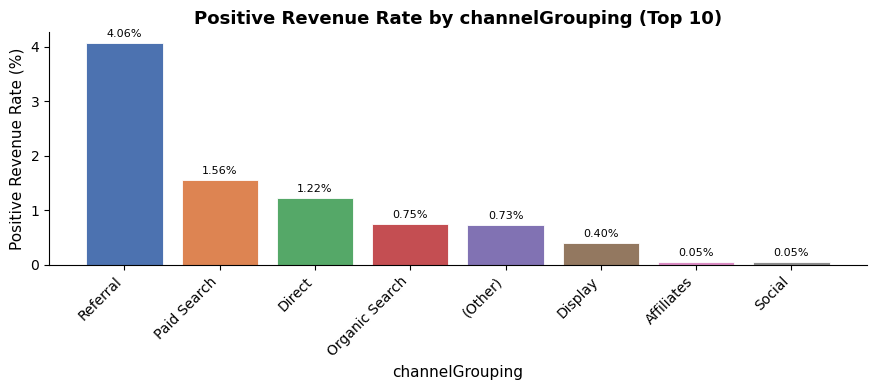

Saved: fig_revenue_rate_channelGrouping.png


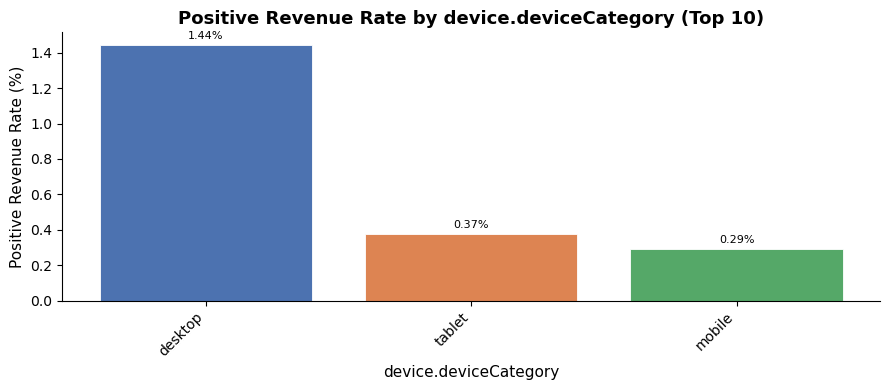

Saved: fig_revenue_rate_device_deviceCategory.png


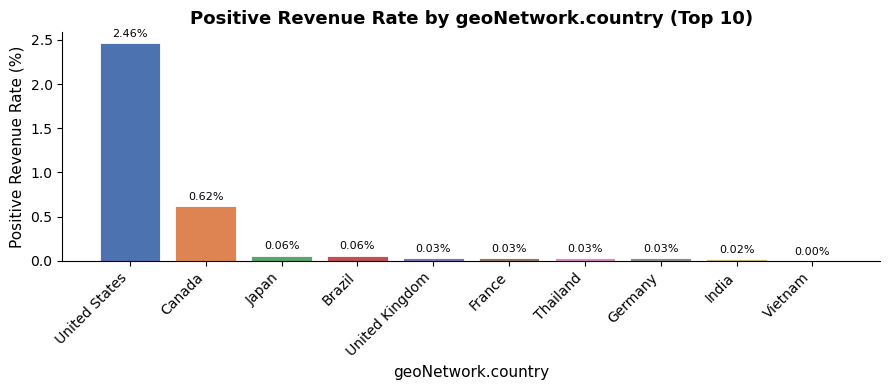

Saved: fig_revenue_rate_geoNetwork_country.png


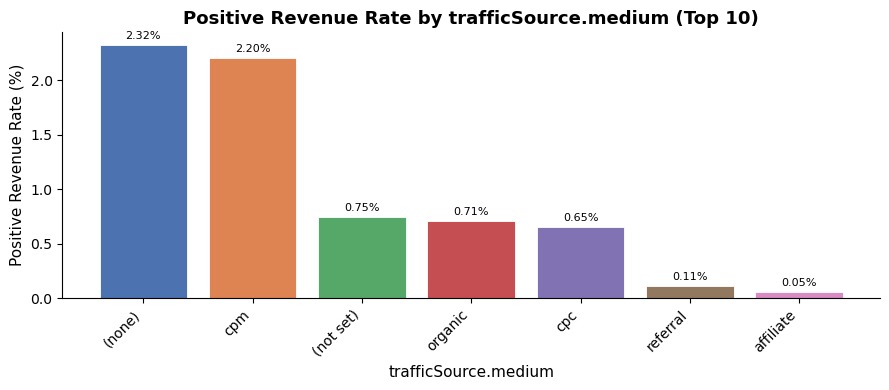

Saved: fig_revenue_rate_trafficSource_medium.png


In [18]:
# Each bar gets its own distinct color
BAR_PALETTE = [
    "#4C72B0", "#DD8452", "#55A868", "#C44E52",
    "#8172B3", "#937860", "#DA8BC3", "#8C8C8C",
    "#CCB974", "#64B5CD"
]

def plot_top_categories(data, col, top_n=10):
    top_values = data[col].fillna("Missing").value_counts().head(top_n).index
    subset = data[data[col].fillna("Missing").isin(top_values)].copy()
    subset[col] = subset[col].fillna("Missing")
    rates = subset.groupby(col)["has_revenue"].mean().sort_values(ascending=False).mul(100)

    colors = [BAR_PALETTE[i % len(BAR_PALETTE)] for i in range(len(rates))]

    fig, ax = plt.subplots(figsize=(9, 4))
    bars = ax.bar(range(len(rates)), rates.values, color=colors, edgecolor="white", linewidth=0.6)
    ax.set_xticks(range(len(rates)))
    ax.set_xticklabels(rates.index, rotation=45, ha="right", fontsize=10)
    ax.bar_label(bars, fmt="{:.2f}%", padding=3, fontsize=8)
    ax.set_title(f"Positive Revenue Rate by {col} (Top {top_n})", fontsize=13, fontweight="bold")
    ax.set_ylabel("Positive Revenue Rate (%)", fontsize=11)
    ax.set_xlabel(col, fontsize=11)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    fname = f"fig_revenue_rate_{col.replace('.', '_')}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fname}")

cols_to_plot = [c for c in ["channelGrouping", "device.deviceCategory",
                              "geoNetwork.country", "trafficSource.medium"] if c in df.columns]
for col in cols_to_plot:
    plot_top_categories(df, col, top_n=10)


### 6.8 Time-Based Analysis

Because data is timestamped, time features may capture seasonality or behavioral cycles. Monthly, day-of-week, and hourly patterns are explored to check whether visit timing predicts purchase likelihood.


In [19]:

monthly = df.groupby("month").agg(
    sessions=("fullVisitorId", "count"),
    positive_rate=("has_revenue", "mean"),
    total_revenue=("revenue", "sum"),
    avg_log_revenue=("log_revenue", "mean")
).reset_index()

monthly["positive_rate"] = monthly["positive_rate"] * 100
monthly

,month,sessions,positive_rate,total_revenue,avg_log_revenue
0,2016-08,74759,1.4968,"154,666,560,000.0000",0.2696
1,2016-09,71032,1.2093,"126,031,240,000.0000",0.2170
2,2016-10,97506,0.8943,"113,329,070,000.0000",0.1596
3,2016-11,113972,0.8063,"119,013,870,000.0000",0.1437
4,2016-12,79124,1.7631,"154,557,930,000.0000",0.3123
5,2017-01,64694,1.0774,"97,877,790,000.0000",0.1920
6,2017-02,62192,1.1384,"108,756,520,000.0000",0.2029
7,2017-03,69931,1.2627,"130,964,270,000.0000",0.2259
8,2017-04,67126,1.3825,"158,788,800,000.0000",0.2468
9,2017-05,65371,1.7056,"121,711,480,000.0000",0.3029


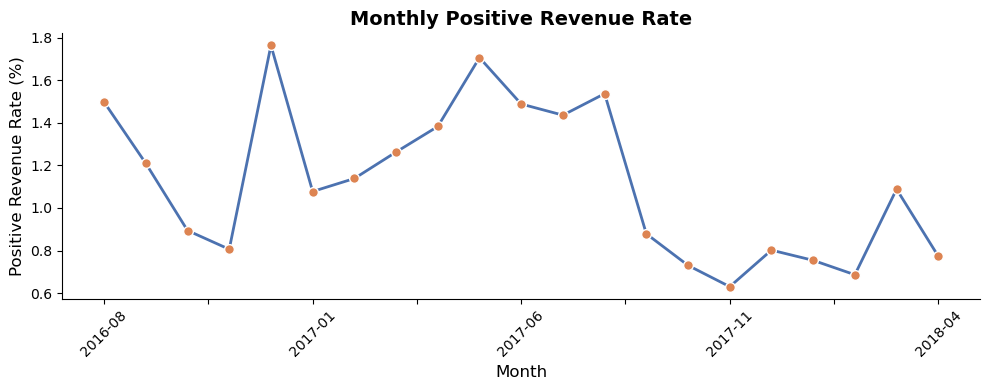

Saved: fig_monthly_revenue_rate.png


In [20]:
fig, ax = plt.subplots(figsize=(10, 4))
df.groupby("month")["has_revenue"].mean().mul(100).plot(
    marker="o", color="#4C72B0", markerfacecolor="#DD8452",
    markeredgecolor="white", markersize=7, linewidth=2, ax=ax)
ax.set_title("Monthly Positive Revenue Rate", fontsize=14, fontweight="bold")
ax.set_ylabel("Positive Revenue Rate (%)", fontsize=12)
ax.set_xlabel("Month", fontsize=12)
ax.tick_params(axis="x", rotation=45)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("fig_monthly_revenue_rate.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig_monthly_revenue_rate.png")


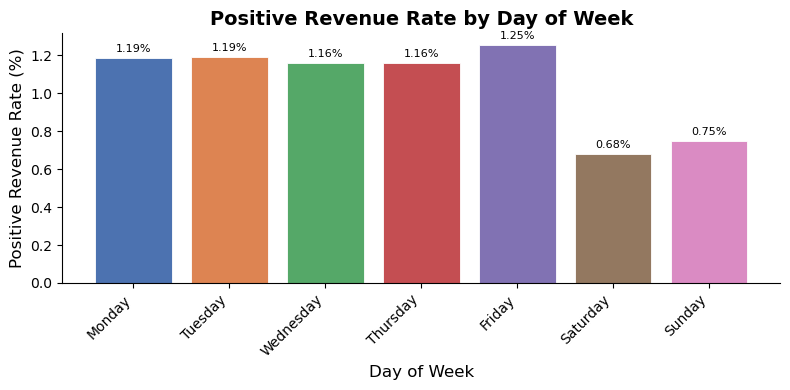

Saved: fig_dow_revenue_rate.png


In [21]:
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow = df.groupby("day_of_week")["has_revenue"].mean().reindex(order).mul(100)

BAR_PALETTE = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3", "#937860", "#DA8BC3"]
day_colors = [BAR_PALETTE[i] for i in range(len(dow))]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(range(len(dow)), dow.values, color=day_colors, edgecolor="white", linewidth=0.6)
ax.set_xticks(range(len(dow)))
ax.set_xticklabels(dow.index, rotation=45, ha="right", fontsize=10)
ax.bar_label(bars, fmt="{:.2f}%", padding=3, fontsize=8)
ax.set_title("Positive Revenue Rate by Day of Week", fontsize=14, fontweight="bold")
ax.set_ylabel("Positive Revenue Rate (%)", fontsize=12)
ax.set_xlabel("Day of Week", fontsize=12)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("fig_dow_revenue_rate.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig_dow_revenue_rate.png")


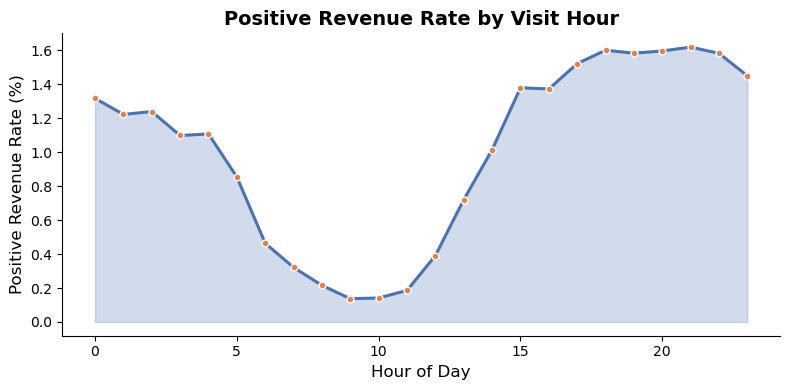

Saved: fig_hourly_revenue_rate.png


In [22]:
hour_rate = df.groupby("hour")["has_revenue"].mean().mul(100)

fig, ax = plt.subplots(figsize=(8, 4))
ax.fill_between(hour_rate.index, hour_rate.values, alpha=0.25, color="#4C72B0")
hour_rate.plot(color="#4C72B0", linewidth=2.2, marker="o", markersize=5,
               markerfacecolor="#DD8452", markeredgecolor="white", ax=ax)
ax.set_title("Positive Revenue Rate by Visit Hour", fontsize=14, fontweight="bold")
ax.set_ylabel("Positive Revenue Rate (%)", fontsize=12)
ax.set_xlabel("Hour of Day", fontsize=12)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("fig_hourly_revenue_rate.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig_hourly_revenue_rate.png")


### 6.9 Visitor-Level Aggregation

The raw dataset is session-level, but revenue prediction may benefit from visitor-level patterns. Aggregating by `fullVisitorId` gives insight into how much of the positive-revenue signal comes from repeat visitors vs. one-time visitors.

> **Note:** These aggregates are for EDA only. For modeling, leakage-safe cumulative features are computed in Section 7 using only prior sessions.


In [23]:

agg_dict = {
    "revenue": ["sum", "max", "mean"],
    "has_revenue": ["max", "mean"],
    "visitNumber": ["max"],
}

optional_numeric = ["totals.hits", "totals.pageviews", "totals.bounces", "totals.newVisits"]
for col in optional_numeric:
    if col in df.columns:
        agg_dict[col] = ["mean", "max"]

agg_dict["date_parsed"] = ["min", "max", "count"]

visitor_df = df.groupby("fullVisitorId").agg(agg_dict)
visitor_df.columns = ["_".join(col).strip() for col in visitor_df.columns]
visitor_df = visitor_df.reset_index()

visitor_df = visitor_df.rename(columns={
    "revenue_sum": "visitor_total_revenue",
    "revenue_max": "visitor_max_session_revenue",
    "revenue_mean": "visitor_avg_session_revenue",
    "has_revenue_max": "visitor_has_any_revenue",
    "has_revenue_mean": "visitor_purchase_session_rate",
    "visitNumber_max": "visitor_max_visit_number",
    "date_parsed_count": "visitor_session_count",
    "date_parsed_min": "first_seen_date",
    "date_parsed_max": "last_seen_date",
})

visitor_df["visitor_active_days"] = (
    visitor_df["last_seen_date"] - visitor_df["first_seen_date"]
).dt.days

visitor_df["visitor_log_total_revenue"] = np.log1p(visitor_df["visitor_total_revenue"])

print("Visitor-level shape:", visitor_df.shape)
visitor_df.head()

Visitor-level shape: (1323730, 20)


,fullVisitorId,visitor_total_revenue,visitor_max_session_revenue,visitor_avg_session_revenue,visitor_has_any_revenue,visitor_purchase_session_rate,visitor_max_visit_number,totals.hits_mean,totals.hits_max,totals.pageviews_mean,totals.pageviews_max,totals.bounces_mean,totals.bounces_max,totals.newVisits_mean,totals.newVisits_max,first_seen_date,last_seen_date,visitor_session_count,visitor_active_days,visitor_log_total_revenue
0,0000000259678714014,0.0000,0.0000,0.0000,0,0.0000,2,9.5000,16,6.5000,10.0000,NaN,NaN,1.0000,1.0000,2017-11-28,2017-11-28,2,0,0.0000
1,0000010278554503158,0.0000,0.0000,0.0000,0,0.0000,1,11.0000,11,8.0000,8.0000,NaN,NaN,1.0000,1.0000,2016-10-20,2016-10-20,1,0,0.0000
2,0000020424342248747,0.0000,0.0000,0.0000,0,0.0000,1,17.0000,17,13.0000,13.0000,NaN,NaN,1.0000,1.0000,2016-11-30,2016-11-30,1,0,0.0000
3,0000027376579751715,0.0000,0.0000,0.0000,0,0.0000,1,6.0000,6,5.0000,5.0000,NaN,NaN,1.0000,1.0000,2017-02-11,2017-02-11,1,0,0.0000
4,0000039460501403861,0.0000,0.0000,0.0000,0,0.0000,1,2.0000,2,2.0000,2.0000,NaN,NaN,1.0000,1.0000,2017-03-27,2017-03-27,1,0,0.0000


In [24]:

visitor_summary = pd.Series({
    "unique_visitors": visitor_df["fullVisitorId"].nunique(),
    "visitors_with_any_revenue": int(visitor_df["visitor_has_any_revenue"].sum()),
    "visitor_positive_rate_pct": round(visitor_df["visitor_has_any_revenue"].mean() * 100, 4),
    "avg_sessions_per_visitor": round(visitor_df["visitor_session_count"].mean(), 4)
})
visitor_summary.to_frame("value")

,value
unique_visitors,"1,323,730.0000"
visitors_with_any_revenue,"16,141.0000"
visitor_positive_rate_pct,1.2194
avg_sessions_per_visitor,1.2905


### 6.10 Data Health Check Summary

A consolidated health report checks dataset shape, data types, missingness levels, duplicate rows, and near-constant columns in one place.


In [25]:
duplicate_rows = int(df.duplicated().sum())

health_summary = pd.DataFrame({
    "metric": [
        "row_count",
        "column_count",
        "duplicate_row_count",
        "duplicate_row_pct",
        "numeric_column_count",
        "object_column_count",
        "datetime_column_count",
        "columns_with_missing_values",
        "columns_over_50pct_missing",
        "near_constant_columns"
    ],
    "value": [
        df.shape[0],
        df.shape[1],
        duplicate_rows,
        round((duplicate_rows / len(df)) * 100, 4) if len(df) else 0,
        int((df.dtypes != "object").sum()),
        int((df.dtypes == "object").sum()),
        int(sum("datetime64" in str(dtype) for dtype in df.dtypes)),
        int((df.isna().sum() > 0).sum()),
        int((df.isna().mean() > 0.50).sum()),
        int((nunique_df["n_unique"] <= 1).sum())
    ]
})

health_summary

,metric,value
0,row_count,"1,708,337.0000"
1,column_count,25.0000
2,duplicate_row_count,0.0000
3,duplicate_row_pct,0.0000
4,numeric_column_count,13.0000
5,object_column_count,12.0000
6,datetime_column_count,2.0000
7,columns_with_missing_values,4.0000
8,columns_over_50pct_missing,1.0000
9,near_constant_columns,0.0000


Key takeaways from the health check:

- The dataset is large enough that memory-efficient loading (Polars) is necessary before converting to pandas.
- Missing values are present in several columns and will require imputation during preprocessing.
- Duplicate rows and near-constant columns are identified early to avoid adding noise without signal.
- Data type validation is important because the dataset mixes nested JSON-extracted fields, numeric behavior columns, and parsed date features.

Overall the dataset is usable, but requires careful preprocessing before modeling.


### 6.11 Outlier Analysis

Revenue and behavior variables can contain very large values. Before deciding to clip or remove outliers, we use IQR-based fencing to quantify how many extreme values exist and whether they likely represent real user behavior or data errors.


In [26]:
outlier_cols = [col for col in ["revenue", "log_revenue", "totals.hits", "totals.pageviews", "visitNumber"] if col in df.columns]

outlier_summary = []
for col in outlier_cols:
    series = df[col].dropna()
    if len(series) == 0:
        continue
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    upper_fence = q3 + 1.5 * iqr
    lower_fence = q1 - 1.5 * iqr
    outlier_count = int(((series < lower_fence) | (series > upper_fence)).sum())
    outlier_summary.append({
        "column": col,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "lower_fence": lower_fence,
        "upper_fence": upper_fence,
        "outlier_count": outlier_count,
        "outlier_pct": round((outlier_count / len(series)) * 100, 4)
    })

outlier_summary_df = pd.DataFrame(outlier_summary)
outlier_summary_df

,column,q1,q3,iqr,lower_fence,upper_fence,outlier_count,outlier_pct
0,revenue,0.0000,0.0000,0.0000,0.0000,0.0000,18514,1.0837
1,log_revenue,0.0000,0.0000,0.0000,0.0000,0.0000,18514,1.0837
2,totals.hits,1.0000,4.0000,3.0000,-3.5000,8.5000,213325,12.4873
3,totals.pageviews,1.0000,4.0000,3.0000,-3.5000,8.5000,172644,10.1074
4,visitNumber,1.0000,1.0000,0.0000,1.0000,1.0000,400907,23.4677


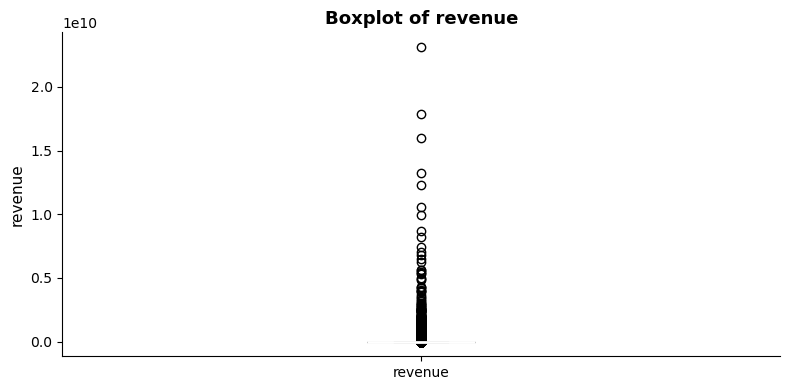

Saved: fig_boxplot_revenue.png


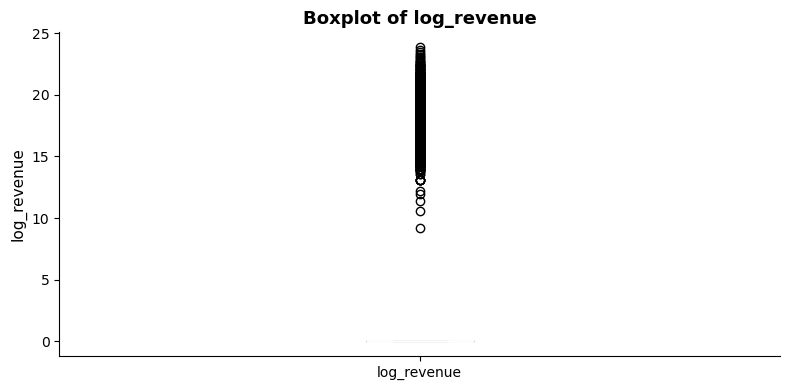

Saved: fig_boxplot_log_revenue.png


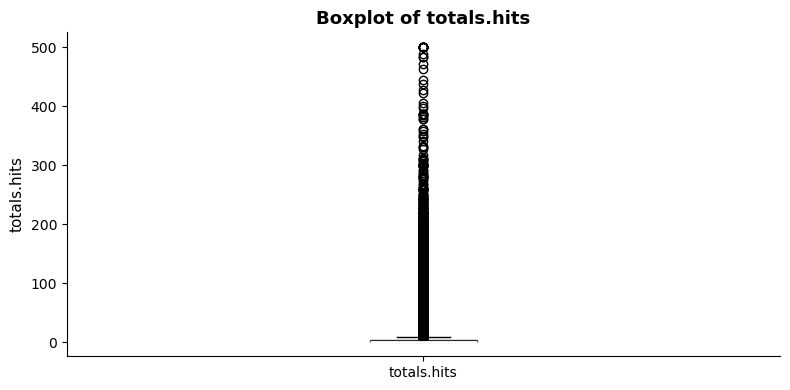

Saved: fig_boxplot_totals_hits.png


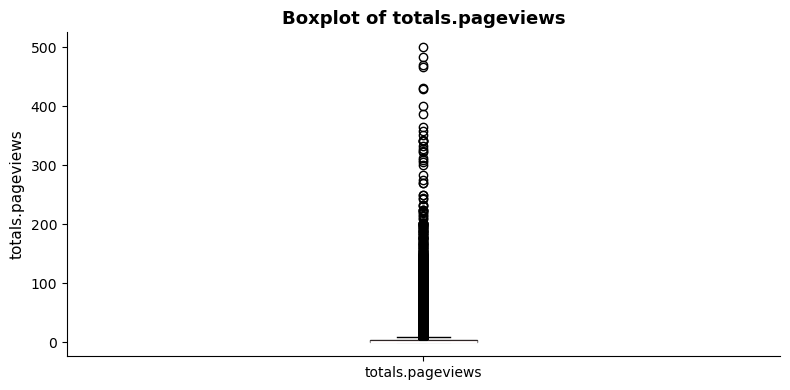

Saved: fig_boxplot_totals_pageviews.png


In [27]:
plot_cols = [col for col in ["revenue", "log_revenue", "totals.hits", "totals.pageviews"] if col in df.columns]
box_colors = ["#4C72B0", "#55A868", "#DD8452", "#C44E52"]

for i, col in enumerate(plot_cols):
    fig, ax = plt.subplots(figsize=(8, 4))
    bp = ax.boxplot(df[col].dropna(), patch_artist=True, notch=False,
                    medianprops=dict(color="white", linewidth=2))
    bp["boxes"][0].set_facecolor(box_colors[i % len(box_colors)])
    bp["boxes"][0].set_alpha(0.8)
    ax.set_title(f"Boxplot of {col}", fontsize=13, fontweight="bold")
    ax.set_ylabel(col, fontsize=11)
    ax.set_xticklabels([col])
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    fname = f"fig_boxplot_{col.replace('.', '_')}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fname}")


The outlier analysis shows that extreme values in revenue and engagement features are structural, not noise.

Key takeaways:

- High revenue values represent genuine high-value sessions and should be retained, not removed.
- High engagement values (hits, pageviews) may reflect unusually active browsing behavior that is predictive of purchase.
- Removing outliers would discard meaningful signal. The preferred approach is log1p transformation for revenue and percentile clipping only for visualization, with robust model choices that handle skewed distributions.


### 6.12 Multivariate Analysis

Individual features rarely explain revenue alone. A correlation matrix and scatter plots against `log_revenue` reveal which combinations of numeric features carry the most signal.

> **EDA finding — `totals.bounces` and `totals.newVisits` dropped:** The original heatmap (run in Section 6.6) showed both columns as entirely dark — near-zero correlation with every other feature. This is a structural artifact: in the raw GA data, `bounces` is `"1"` or null (not `"1"`/`"0"`), and `newVisits` follows the same pattern. Polars regex extraction retrieves the literal `"1"` value, so after numeric conversion the column is either `1.0` or `NaN`. Median imputation then fills all `NaN` values with the median (which is `NaN` for a mostly-null column, or `1.0` depending on sparsity), collapsing the column to near-constant. The signal is gone. `visitNumber` already captures the new-vs-returning distinction more reliably (first visit → `visitNumber == 1`). Both features are excluded from the correlation analysis and the final feature set below.


In [28]:
# totals.bounces and totals.newVisits are excluded from the correlation analysis.
# Their binary/null structure means median imputation collapses their variance to near-constant,
# producing zero (or near-zero) correlations with all other features.
# This is visible in the heatmap as entirely dark rows/columns — a structural artifact,
# not a genuine lack of relationship. Both features are dropped from the modeling feature set.

corr_cols = [col for col in [
    "revenue",
    "log_revenue",
    "has_revenue",
    "totals.hits",
    "totals.pageviews",
    "visitNumber",
    "hour"
] if col in df.columns]

corr_df = df[corr_cols].corr(numeric_only=True).round(3)
corr_df


,revenue,log_revenue,has_revenue,totals.hits,totals.pageviews,visitNumber,hour
revenue,1.0000,0.3180,0.2860,0.1450,0.1450,0.0550,0.0110
log_revenue,0.3180,1.0000,0.9980,0.3610,0.3790,0.0200,0.0250
has_revenue,0.2860,0.9980,1.0000,0.3570,0.3750,0.0190,0.0250
totals.hits,0.1450,0.3610,0.3570,1.0000,0.9800,0.0340,0.0190
totals.pageviews,0.1450,0.3790,0.3750,0.9800,1.0000,0.0380,0.0210
visitNumber,0.0550,0.0200,0.0190,0.0340,0.0380,1.0000,0.0210
hour,0.0110,0.0250,0.0250,0.0190,0.0210,0.0210,1.0000


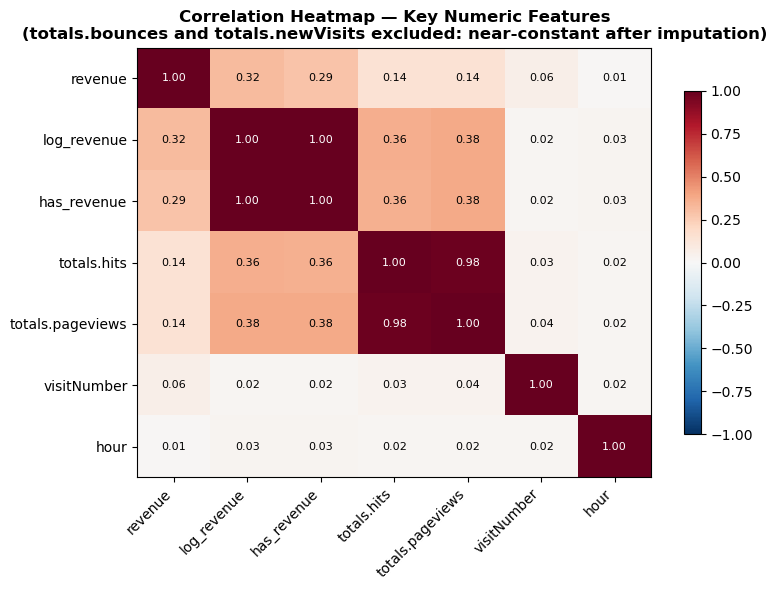

Saved: fig_correlation_heatmap.png


In [29]:
if len(corr_cols) >= 2:
    fig, ax = plt.subplots(figsize=(8, 6))
    cmap = plt.cm.RdBu_r
    im = ax.imshow(corr_df, aspect="auto", cmap=cmap, vmin=-1, vmax=1)
    plt.colorbar(im, ax=ax, shrink=0.8)
    ax.set_xticks(range(len(corr_df.columns)))
    ax.set_yticks(range(len(corr_df.index)))
    ax.set_xticklabels(corr_df.columns, rotation=45, ha="right", fontsize=10)
    ax.set_yticklabels(corr_df.index, fontsize=10)
    # Annotate cells
    for r in range(len(corr_df.index)):
        for c in range(len(corr_df.columns)):
            val = corr_df.iloc[r, c]
            ax.text(c, r, f"{val:.2f}", ha="center", va="center",
                    fontsize=8, color="white" if abs(val) > 0.5 else "black")
    ax.set_title(
        "Correlation Heatmap — Key Numeric Features\n"
        "(totals.bounces and totals.newVisits excluded: near-constant after imputation)",
        fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig("fig_correlation_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: fig_correlation_heatmap.png")


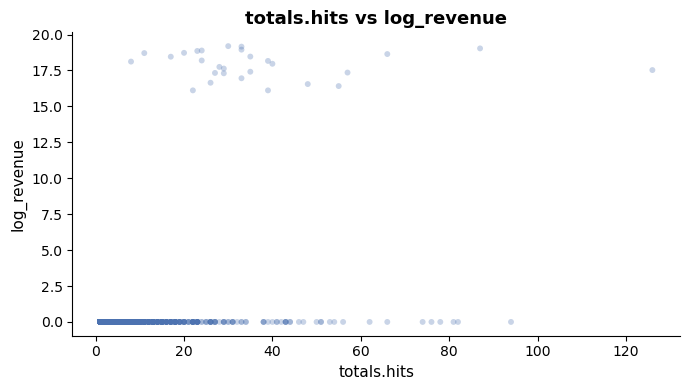

Saved: fig_scatter_totals_hits_vs_log_revenue.png


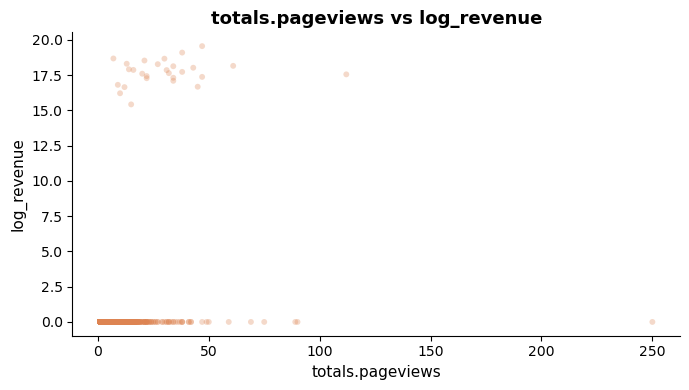

Saved: fig_scatter_totals_pageviews_vs_log_revenue.png


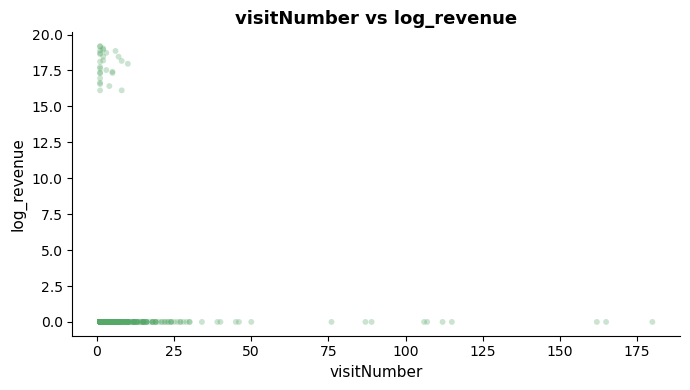

Saved: fig_scatter_visitNumber_vs_log_revenue.png


In [30]:
scatter_cols = [col for col in ["totals.hits", "totals.pageviews", "visitNumber"] if col in df.columns]
scatter_palette = ["#4C72B0", "#DD8452", "#55A868"]

for i, col in enumerate(scatter_cols):
    sample_df = df[[col, "log_revenue"]].dropna().sample(
        min(3000, len(df[[col, "log_revenue"]].dropna())), random_state=42)
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.scatter(sample_df[col], sample_df["log_revenue"],
               alpha=0.3, color=scatter_palette[i % len(scatter_palette)], edgecolors="none", s=18)
    ax.set_title(f"{col} vs log_revenue", fontsize=13, fontweight="bold")
    ax.set_xlabel(col, fontsize=11)
    ax.set_ylabel("log_revenue", fontsize=11)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    fname = f"fig_scatter_{col.replace('.', '_')}_vs_log_revenue.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fname}")


The multivariate analysis confirms that no single feature fully explains revenue, which is expected for session-level e-commerce data.

Key takeaways:

- Engagement features (hits, pageviews, visitNumber) show the clearest positive relationship with log revenue and are retained in the final feature set.
- Some pairwise correlations are weak, but weak univariate relationships do not rule out usefulness in a tree-based model that can combine multiple signals.
- This supports the use of ensemble models (Random Forest, XGBoost, LightGBM) rather than any single-feature rule.

The complete feature selection decisions driven by EDA are documented in Section 6.13.


### 6.13 EDA Summary, Feature Selection Decisions, and Modeling Hypotheses

The subsections below close the EDA chapter. First, every EDA finding is mapped
directly to a keep / drop / transform / engineer decision. Second, the hypotheses
that will be tested in Section 8 are stated.

---

#### EDA-Driven Feature Selection Decisions

The table below is the explicit bridge from EDA observations to the final feature set.
Every column that appears in (or is excluded from) the modeling pipeline has a row here.

| Feature | Decision | EDA Finding That Drove It |
|---|---|---|
| `totals.hits` | **Keep** | Section 6.6: mean hits is visibly higher in revenue-generating sessions; Section 6.12: positive correlation with `log_revenue` in scatter plot |
| `totals.pageviews` | **Keep** | Section 6.6: same pattern as hits — higher pageview counts in purchase sessions; scatter (6.12) confirms monotone trend |
| `visitNumber` | **Keep** | Section 6.6: repeat visitors show higher purchase rates; also proxies the `newVisits` signal more reliably (see below) |
| `totals.bounces` | **Drop** | Section 6.4: field is `"1"`-or-null in raw GA data, not `"1"`/`"0"`. After numeric conversion and median imputation the column collapses to near-constant. Section 6.12 heatmap: entirely dark row — near-zero correlation with everything. No usable variance. |
| `totals.newVisits` | **Drop** | Section 6.4 / 6.12: same binary/null structure as `bounces`; imputation destroys variance. `visitNumber` already captures the new-vs-returning distinction (`visitNumber == 1` ↔ new visit). |
| `channelGrouping` | **Keep** | Section 6.7: bar chart shows Organic Search and Direct channels have measurably higher positive revenue rates than Social or Display; strong categorical signal |
| `trafficSource.medium` | **Keep** | Section 6.7: `organic` and `(none)` (direct) mediums have higher purchase rates than `cpc` or `referral`; included as a complementary traffic-source signal |
| `trafficSource.source` | **Keep (top-25 grouped)** | Section 6.7: high-cardinality but top sources differ in purchase rate; rare sources mapped to "Other" to avoid sparse one-hot columns (Section 7.5) |
| `device.deviceCategory` | **Keep** | Section 6.7: desktop sessions have substantially higher purchase rates than mobile or tablet; EDA bar chart shows ~3–5× difference |
| `device.browser` | **Keep (top-25 grouped)** | Section 6.7: Chrome dominates volume; high-cardinality so rare browsers grouped to "Other" |
| `device.operatingSystem` | **Keep (top-25 grouped)** | Section 6.7: Windows and Macintosh sessions show higher purchase rates than Android/iOS; included as device complement |
| `geoNetwork.country` | **Keep (top-25 grouped)** | Section 6.7: United States dominates revenue; purchase rate varies significantly by country; rare countries grouped to "Other" |
| `month` | **Keep** | Section 6.8: monthly positive revenue rate chart shows seasonality peaks (holiday season); useful temporal signal |
| `day_of_week` | **Keep** | Section 6.8: weekday vs. weekend pattern visible in bar chart; moderate but consistent signal |
| `hour` | **Keep** | Section 6.8: hourly rate curve shows intra-day variation; included as a lightweight time feature |
| Visitor history features | **Engineer (leakage-safe)** | Section 6.9: visitor-level aggregation shows that visitors who have purchased before account for a disproportionate share of future revenue. EDA visitor summary confirms this pattern. Features must be leakage-safe (prior sessions only — Section 7.4). |
| `totals.transactionRevenue` (raw) | **Transform → `log_revenue`** | Section 6.3: raw revenue is strongly right-skewed across several orders of magnitude; log1p transformation produces a more symmetric distribution suitable for regression |
| `has_revenue` (binary) | **Engineer** | Section 6.3: ~98%+ of sessions are zero-revenue; zero-inflation justifies a separate binary classification target for the two-step model |

---

#### Summary of EDA Findings

- **Revenue is heavily zero-inflated** (~98%+ of sessions produce no revenue); this directly motivates the two-step model design.
- **Positive revenue is strongly right-skewed** — log1p transformation is essential for regression.
- **Session behavior features** (hits, pageviews, visit number) show consistently higher means in revenue-generating sessions; `bounces` and `newVisits` do not because their variance is destroyed by imputation.
- **Categorical groups** (channel, device type, traffic source, country) vary substantially in purchase rate — device category and channel grouping show the largest gaps.
- **Time-based patterns** (monthly seasonality, day-of-week, hour) show moderate but consistent variation worth capturing as features.
- **Visitor-level history** is promising — visitors who purchased before are disproportionately likely to purchase again — but must be computed leakage-safely using only prior sessions.

---

#### Hypotheses to Test in Modeling

1. Sessions with higher engagement (more hits, pageviews) are more likely to generate revenue.
2. Some traffic channels and device types are significantly more associated with purchases.
3. Leakage-safe visitor history features will outperform session-only features.
4. A two-step model (classify purchase → regress revenue) will outperform a single-stage regressor due to zero inflation.
5. Tree-based models (Random Forest, XGBoost, LightGBM) will outperform linear models on this nonlinear, mixed-type dataset.
6. XGBoost and LightGBM will outperform vanilla Random Forest due to gradient boosting and built-in regularization.


---
## 7. Feature Engineering

Section 6.13 established which features to keep, drop, transform, or engineer based on EDA findings.
This section implements those decisions: leakage-safe visitor history features are computed,
high-cardinality categoricals are grouped, numeric features are imputed, and the final
modeling table is assembled for scikit-learn.

### 7.1 Feature Groups Used

The final feature set is drawn from six groups, each directly motivated by EDA:

| Feature Group | Features | EDA Motivation |
|---|---|---|
| Session behavior | hits, pageviews, visitNumber | Sections 6.6, 6.12: higher engagement → higher revenue likelihood; `bounces` and `newVisits` dropped (near-constant after imputation) |
| Traffic source | channelGrouping, medium, source | Section 6.7: channel groups vary substantially in purchase rate |
| Device | deviceCategory, browser, operatingSystem | Section 6.7: desktop sessions have ~3–5× higher purchase rate than mobile |
| Geography | country | Section 6.7: country-level purchase rates differ significantly; US dominates revenue |
| Timing | month, day_of_week, hour | Section 6.8: seasonal, day-of-week, and intra-day patterns observed |
| Visitor history | prior session count, total revenue, purchase rate, avg/max revenue | Section 6.9: prior purchasing behavior is highly predictive; must be leakage-safe |


In [31]:

# Polars-first setup for the modeling section
# Reuse the full Polars dataframe created earlier instead of reading/flattening the CSV again.

if "pl_df_full" not in globals():
    pl_df_full = load_ga_data_full_polars(DATA_PATH)

# Use all rows for modeling feature preparation. If the kernel is still too slow, change this to `.head(100_000)`.
pl_df = pl_df_full.clone()

print("Polars modeling shape:", pl_df.shape)
pl_df.head()


Polars modeling shape: (1708337, 16)


channelGrouping,date,fullVisitorId,visitNumber,visitStartTime,totals.transactionRevenue,totals.hits,totals.pageviews,totals.bounces,totals.newVisits,device.deviceCategory,device.browser,device.operatingSystem,geoNetwork.country,trafficSource.medium,trafficSource.source
str,str,str,i64,i64,str,str,str,str,str,str,str,str,str,str,str
"""Organic Search""","""20171016""","""3162355547410993243""",1,1508198450,null,"""1""","""1""","""1""","""1""","""desktop""","""Firefox""","""Windows""","""Germany""","""organic""","""google"""
"""Referral""","""20171016""","""8934116514970143966""",6,1508176307,null,"""2""","""2""",null,null,"""desktop""","""Chrome""","""Chrome OS""","""United States""","""referral""","""sites.google.com"""
"""Direct""","""20171016""","""7992466427990357681""",1,1508201613,null,"""2""","""2""",null,"""1""","""mobile""","""Chrome""","""Android""","""United States""","""(none)""","""(direct)"""
"""Organic Search""","""20171016""","""9075655783635761930""",1,1508169851,null,"""2""","""2""",null,"""1""","""desktop""","""Chrome""","""Windows""","""Turkey""","""organic""","""google"""
"""Organic Search""","""20171016""","""6960673291025684308""",1,1508190552,null,"""2""","""2""",null,"""1""","""desktop""","""Chrome""","""Windows""","""Mexico""","""organic""","""google"""


In [32]:
# Target and basic feature engineering in Polars
pl_df = pl_df.with_columns([
    pl.col("totals.transactionRevenue")
      .cast(pl.Float64, strict=False)
      .fill_null(0)
      .alias("revenue"),

    pl.col("date")
      .str.strptime(pl.Date, "%Y%m%d", strict=False)
      .alias("date_parsed"),

    pl.from_epoch(pl.col("visitStartTime").cast(pl.Int64, strict=False), time_unit="s")
      .alias("visit_start_dt"),
])

pl_df = pl_df.with_columns([
    (pl.col("revenue") > 0).cast(pl.Int8).alias("has_revenue"),
    pl.col("revenue").log1p().alias("log_revenue"),
    pl.col("date_parsed").dt.year().alias("year"),
    pl.col("date_parsed").dt.strftime("%Y-%m").alias("month"),
    pl.col("date_parsed").dt.weekday().alias("day_of_week"),
    pl.col("visit_start_dt").dt.hour().alias("hour"),
])

for col in ["totals.hits", "totals.pageviews", "totals.bounces", "totals.newVisits", "visitNumber"]:
    if col in pl_df.columns:
        pl_df = pl_df.with_columns(pl.col(col).cast(pl.Float64, strict=False).alias(col))

pl_df.select(["fullVisitorId", "revenue", "has_revenue", "log_revenue", "date_parsed", "visit_start_dt"]).head()

fullVisitorId,revenue,has_revenue,log_revenue,date_parsed,visit_start_dt
str,f64,i8,f64,date,datetime[μs]
"""3162355547410993243""",0.0,0,0.0,2017-10-16,2017-10-17 00:00:50
"""8934116514970143966""",0.0,0,0.0,2017-10-16,2017-10-16 17:51:47
"""7992466427990357681""",0.0,0,0.0,2017-10-16,2017-10-17 00:53:33
"""9075655783635761930""",0.0,0,0.0,2017-10-16,2017-10-16 16:04:11
"""6960673291025684308""",0.0,0,0.0,2017-10-16,2017-10-16 21:49:12


### 7.2 Sample Representativeness Check

The sample used for modeling is validated against the full dataset to confirm that positive revenue rate, channel distribution, and revenue distribution are consistent. This ensures that any model trained on a subset generalizes to the full population.

In [33]:

# Use the already-loaded full Polars dataframe for the representativeness check.
# This avoids reading train_v2.csv multiple times.
full_check = pl_df_full.select([
    "fullVisitorId",
    "date",
    "channelGrouping",
    "totals.transactionRevenue",
    "trafficSource.source",
]).with_columns([
    pl.col("totals.transactionRevenue")
        .cast(pl.Float64, strict=False)
        .fill_null(0)
        .alias("revenue"),

    pl.col("trafficSource.source")
        .fill_null("Missing")
        .alias("trafficSource.source"),

    pl.col("date")
        .str.strptime(pl.Date, "%Y%m%d", strict=False)
        .alias("date_parsed"),
])

full_check = full_check.with_columns([
    (pl.col("revenue") > 0).cast(pl.Int8).alias("has_revenue"),
    pl.col("revenue").log1p().alias("log_revenue"),
])

sample_check = full_check.head(50_000)

def representativeness_summary(data: pl.DataFrame, label: str) -> pl.DataFrame:
    return data.select([
        pl.lit(label).alias("dataset"),
        pl.len().alias("rows"),
        pl.col("fullVisitorId").n_unique().alias("unique_visitors"),
        (pl.col("has_revenue").mean() * 100).round(4).alias("positive_revenue_rate_pct"),
        pl.col("date_parsed").min().alias("min_date"),
        pl.col("date_parsed").max().alias("max_date"),
        pl.col("revenue").mean().round(4).alias("mean_revenue"),
        pl.col("revenue").median().alias("median_revenue"),
        pl.col("revenue").quantile(0.90).alias("revenue_p90"),
        pl.col("revenue").quantile(0.99).alias("revenue_p99"),
        pl.col("revenue").max().alias("max_revenue"),
    ])

sample_vs_full = pl.concat([
    representativeness_summary(sample_check, "50k_sample"),
    representativeness_summary(full_check, "full_dataset"),
])

sample_vs_full


dataset,rows,unique_visitors,positive_revenue_rate_pct,min_date,max_date,mean_revenue,median_revenue,revenue_p90,revenue_p99,max_revenue
str,u32,u32,f64,date,date,f64,f64,f64,f64,f64
"""50k_sample""",50000,45639,0.936,2016-08-11,2018-04-15,1203764.4,0.0,0.0,0.0,5.4980e9
"""full_dataset""",1708337,1323730,1.0837,2016-08-01,2018-04-30,1.3559e6,0.0,0.0,1.231e7,2.3130e10


In [34]:
sample_channel = (
    sample_check
    .group_by("channelGrouping")
    .agg(pl.len().alias("sample_sessions"))
    .with_columns((pl.col("sample_sessions") / pl.col("sample_sessions").sum() * 100).alias("sample_pct"))
)

full_channel = (
    full_check
    .group_by("channelGrouping")
    .agg(pl.len().alias("full_sessions"))
    .with_columns((pl.col("full_sessions") / pl.col("full_sessions").sum() * 100).alias("full_pct"))
)

channel_compare = (
    sample_channel
    .join(full_channel, on="channelGrouping", how="full")
    .fill_null(0)
    .with_columns((pl.col("sample_pct") - pl.col("full_pct")).round(4).alias("pct_point_diff"))
    .sort("full_sessions", descending=True)
)

channel_compare

channelGrouping,sample_sessions,sample_pct,channelGrouping_right,full_sessions,full_pct,pct_point_diff
str,u32,f64,str,u32,f64,f64
"""Organic Search""",21270,42.54,"""Organic Search""",738963,43.256278,-0.7163
"""Social""",12083,24.166,"""Social""",354971,20.778746,3.3873
"""Direct""",7305,14.61,"""Direct""",273134,15.988297,-1.3783
"""Referral""",6179,12.358,"""Referral""",211307,12.369164,-0.0112
"""Display""",940,1.88,"""Display""",51283,3.001925,-1.1219
"""Paid Search""",1279,2.558,"""Paid Search""",45627,2.670843,-0.1128
"""Affiliates""",943,1.886,"""Affiliates""",32915,1.926728,-0.0407
"""(Other)""",1,0.002,"""(Other)""",137,0.008019,-0.006


### 7.4 Leakage-Safe Visitor History Features

Visitor-level aggregates can leak future information if they include the current session's revenue. To prevent this, features are computed using **only prior sessions** for each visitor: sessions are sorted by visitor and timestamp, then cumulative statistics are shifted so the current row is excluded.

**Leakage-safe features created:**

- `visitor_prior_session_count` — number of prior sessions for this visitor  
- `visitor_prior_total_revenue` — cumulative revenue from prior sessions  
- `visitor_prior_avg_session_revenue` — average revenue per prior session  
- `visitor_prior_max_session_revenue` — maximum single-session revenue in prior sessions  
- `visitor_prior_purchase_sessions` — count of prior sessions with revenue  
- `visitor_prior_purchase_rate` — fraction of prior sessions with any revenue  
- `visitor_prior_log_total_revenue` — log1p of cumulative prior revenue  


In [35]:
# Sort by visitor and time before calculating past-only cumulative features
pl_df = pl_df.sort(["fullVisitorId", "visit_start_dt"])

pl_df = pl_df.with_columns([
    pl.col("revenue")
      .cum_sum()
      .shift(1)
      .over("fullVisitorId")
      .fill_null(0)
      .alias("visitor_prior_total_revenue"),

    pl.col("revenue")
      .cum_max()
      .shift(1)
      .over("fullVisitorId")
      .fill_null(0)
      .alias("visitor_prior_max_session_revenue"),

    pl.col("has_revenue")
      .cum_sum()
      .shift(1)
      .over("fullVisitorId")
      .fill_null(0)
      .alias("visitor_prior_purchase_sessions"),

    pl.int_range(pl.len())
      .over("fullVisitorId")
      .alias("visitor_prior_session_count"),
])

pl_df = pl_df.with_columns([
    (
        pl.col("visitor_prior_total_revenue") /
        pl.when(pl.col("visitor_prior_session_count") > 0)
          .then(pl.col("visitor_prior_session_count"))
          .otherwise(1)
    ).alias("visitor_prior_avg_session_revenue"),

    (
        pl.col("visitor_prior_purchase_sessions") /
        pl.when(pl.col("visitor_prior_session_count") > 0)
          .then(pl.col("visitor_prior_session_count"))
          .otherwise(1)
    ).alias("visitor_prior_purchase_rate"),

    pl.col("visitor_prior_total_revenue").log1p().alias("visitor_prior_log_total_revenue"),
])

pl_df.select([
    "fullVisitorId",
    "visit_start_dt",
    "revenue",
    "visitor_prior_session_count",
    "visitor_prior_total_revenue",
    "visitor_prior_avg_session_revenue",
    "visitor_prior_max_session_revenue",
    "visitor_prior_purchase_rate",
]).head(10)

fullVisitorId,visit_start_dt,revenue,visitor_prior_session_count,visitor_prior_total_revenue,visitor_prior_avg_session_revenue,visitor_prior_max_session_revenue,visitor_prior_purchase_rate
str,datetime[μs],f64,i64,f64,f64,f64,f64
"""0000000259678714014""",2017-11-28 23:33:21,0.0,0,0.0,0.0,0.0,0.0
"""0000000259678714014""",2017-11-29 00:19:40,0.0,1,0.0,0.0,0.0,0.0
"""0000010278554503158""",2016-10-21 05:57:46,0.0,0,0.0,0.0,0.0,0.0
"""0000020424342248747""",2016-12-01 07:55:01,0.0,0,0.0,0.0,0.0,0.0
"""0000027376579751715""",2017-02-12 02:24:53,0.0,0,0.0,0.0,0.0,0.0
"""0000039460501403861""",2017-03-27 15:45:16,0.0,0,0.0,0.0,0.0,0.0
"""0000040862739425590""",2017-02-11 18:09:31,0.0,0,0.0,0.0,0.0,0.0
"""0000040862739425590""",2017-02-11 18:47:04,0.0,1,0.0,0.0,0.0,0.0
"""0000049363351866189""",2017-09-19 00:03:34,0.0,0,0.0,0.0,0.0,0.0


### 7.5 Preprocessing Details

Categorical variables are filled with `"Missing"` and one-hot encoded. High-cardinality
features (`trafficSource.source`, `device.browser`, `geoNetwork.country`) are reduced
by keeping the top 25 most common values and mapping all others to `"Other"`. Numeric
variables use median imputation. Standard scaling is applied for linear and logistic
models; tree-based models use the unscaled pipeline.


In [36]:
numeric_features = [
    "totals.hits",
    "totals.pageviews",
    "visitNumber",
    # "totals.bounces" — DROPPED: binary/null structure collapses to near-constant after median imputation
    # "totals.newVisits" — DROPPED: same issue; signal already captured by visitNumber
    "hour",
    "visitor_prior_session_count",
    "visitor_prior_log_total_revenue",
    "visitor_prior_avg_session_revenue",
    "visitor_prior_max_session_revenue",
    "visitor_prior_purchase_rate",
]

categorical_features = [
    "channelGrouping",
    "trafficSource.medium",
    "trafficSource.source",
    "device.deviceCategory",
    "device.browser",
    "device.operatingSystem",
    "geoNetwork.country",
    "month",
    "day_of_week",
]

numeric_features = [col for col in numeric_features if col in pl_df.columns]
categorical_features = [col for col in categorical_features if col in pl_df.columns]

high_cardinality_cols = ["trafficSource.source", "device.browser", "geoNetwork.country"]

def group_rare_categories_polars(data: pl.DataFrame, col: str, top_k: int = 25) -> pl.DataFrame:
    if col not in data.columns:
        return data

    temp_col = f"__{col}_clean"
    counts = (
        data
        .with_columns(pl.col(col).fill_null("Missing").cast(pl.Utf8).alias(temp_col))
        .group_by(temp_col)
        .agg(pl.len().alias("count"))
        .sort("count", descending=True)
        .head(top_k)
    )
    top_values = counts.get_column(temp_col).to_list()

    return data.with_columns(
        pl.when(pl.col(col).fill_null("Missing").cast(pl.Utf8).is_in(top_values))
          .then(pl.col(col).fill_null("Missing").cast(pl.Utf8))
          .otherwise(pl.lit("Other"))
          .alias(col)
    )

model_pl = pl_df.clone()

for col in categorical_features:
    model_pl = model_pl.with_columns(pl.col(col).fill_null("Missing").cast(pl.Utf8).alias(col))

for col in high_cardinality_cols:
    model_pl = group_rare_categories_polars(model_pl, col, top_k=25)

for col in numeric_features:
    model_pl = model_pl.with_columns(pl.col(col).cast(pl.Float64, strict=False).alias(col))

model_cols = ["fullVisitorId", "log_revenue", "has_revenue"] + numeric_features + categorical_features
model_pl = model_pl.select(model_cols).drop_nulls(subset=["fullVisitorId", "log_revenue", "has_revenue"])

print("Modeling table shape:", model_pl.shape)
model_pl.head()

Modeling table shape: (1708337, 21)


fullVisitorId,log_revenue,has_revenue,totals.hits,totals.pageviews,visitNumber,hour,visitor_prior_session_count,visitor_prior_log_total_revenue,visitor_prior_avg_session_revenue,visitor_prior_max_session_revenue,visitor_prior_purchase_rate,channelGrouping,trafficSource.medium,trafficSource.source,device.deviceCategory,device.browser,device.operatingSystem,geoNetwork.country,month,day_of_week
str,f64,i8,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,str,str,str,str,str
"""0000000259678714014""",0.0,0,3.0,3.0,1.0,23.0,0.0,0.0,0.0,0.0,0.0,"""Organic Search""","""organic""","""google""","""desktop""","""Chrome""","""Macintosh""","""United States""","""2017-11""","""2"""
"""0000000259678714014""",0.0,0,16.0,10.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,"""Organic Search""","""organic""","""google""","""desktop""","""Chrome""","""Macintosh""","""United States""","""2017-11""","""2"""
"""0000010278554503158""",0.0,0,11.0,8.0,1.0,5.0,0.0,0.0,0.0,0.0,0.0,"""Organic Search""","""organic""","""google""","""desktop""","""Chrome""","""Macintosh""","""Other""","""2016-10""","""4"""
"""0000020424342248747""",0.0,0,17.0,13.0,1.0,7.0,0.0,0.0,0.0,0.0,0.0,"""Organic Search""","""(none)""","""(direct)""","""desktop""","""Chrome""","""Windows""","""Other""","""2016-11""","""3"""
"""0000027376579751715""",0.0,0,6.0,5.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,"""Organic Search""","""(none)""","""(direct)""","""desktop""","""Chrome""","""Macintosh""","""United States""","""2017-02""","""6"""


In [37]:
# Convert only the final modeling table for scikit-learn.
model_pd = model_pl.to_pandas()

X = model_pd[numeric_features + categorical_features]
y_reg = model_pd["log_revenue"]
y_cls = model_pd["has_revenue"]
groups = model_pd["fullVisitorId"]

splitter = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, test_idx = next(splitter.split(X, y_reg, groups=groups))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_reg_train = y_reg.iloc[train_idx]
y_reg_test = y_reg.iloc[test_idx]
y_cls_train = y_cls.iloc[train_idx]
y_cls_test = y_cls.iloc[test_idx]

print("Train rows:", len(X_train))
print("Test rows:", len(X_test))
print("Train visitors:", groups.iloc[train_idx].nunique())
print("Test visitors:", groups.iloc[test_idx].nunique())
print("Visitor overlap:", len(set(groups.iloc[train_idx]) & set(groups.iloc[test_idx])))

Train rows: 1366852
Test rows: 341485
Train visitors: 1058984
Test visitors: 264746
Visitor overlap: 0


In [38]:
numeric_preprocess_scaled = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

numeric_preprocess_unscaled = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

linear_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_preprocess_scaled, numeric_features),
        ("cat", categorical_preprocess, categorical_features),
    ]
)

tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_preprocess_unscaled, numeric_features),
        ("cat", categorical_preprocess, categorical_features),
    ]
)

---
## 8. Modeling

### 8.1 Train/Test Split Strategy

Data is split by `fullVisitorId` using `GroupShuffleSplit` (80/20). This ensures the same visitor
does not appear in both training and test sets, preventing visitor-level leakage. This design
decision is directly motivated by the leakage risk identified in the literature survey (Section 2).

### 8.2 Models

The following models are evaluated across Sections 8.3 and 8.4:

| Section | Model | Type | Purpose |
|---|---|---|---|
| 8.3 | Zero Revenue Baseline | Naive | Lower bound: predicts 0 for every session |
| 8.3 | Mean Log Revenue Baseline | Naive | Predicts training mean for every session |
| 8.3 | Linear Regression | Supervised | Simple linear baseline |
| 8.3 | Random Forest Regressor | Supervised | Nonlinear tree ensemble baseline |
| 8.3 | Two-Step Logistic + RF | Supervised | Explicit zero-inflation handling |
| 8.4 | XGBoost Regressor | Supervised | Gradient boosting; tests Hypothesis 6 |
| 8.4 | LightGBM Regressor | Supervised | Gradient boosting; leaf-wise growth |
| 8.4 | Two-Step Logistic + XGBoost | Supervised | Two-step with XGB second stage |
| 8.4 | Two-Step Logistic + LightGBM | Supervised | Two-step with LGBM second stage |

### 8.3 Model Training


In [39]:
def evaluate_regression(name: str, y_true, y_pred) -> dict:
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    mae = mean_absolute_error(y_true, y_pred)
    return {
        "model": name,
        "rmse_log_revenue": rmse,
        "mae_log_revenue": mae,
    }

results = []

# Baseline 1: predict zero revenue for every session.
zero_pred = np.zeros_like(y_reg_test, dtype=float)
results.append(evaluate_regression("Zero Revenue Baseline", y_reg_test, zero_pred))

# Baseline 2: predict mean log revenue from the training set.
mean_pred = np.full_like(y_reg_test, y_reg_train.mean(), dtype=float)
results.append(evaluate_regression("Mean Log Revenue Baseline", y_reg_test, mean_pred))

# Linear regression baseline.
linear_model = Pipeline(steps=[
    ("preprocess", linear_preprocessor),
    ("model", LinearRegression()),
])

linear_model.fit(X_train, y_reg_train)
linear_pred = np.clip(linear_model.predict(X_test), 0, None)
results.append(evaluate_regression("Linear Regression", y_reg_test, linear_pred))

# Random forest regression.
rf_model = Pipeline(steps=[
    ("preprocess", tree_preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100,
        max_depth=12,
        min_samples_leaf=10,
        random_state=42,
        n_jobs=-1,
    )),
])

rf_model.fit(X_train, y_reg_train)
rf_pred = np.clip(rf_model.predict(X_test), 0, None)
results.append(evaluate_regression("Random Forest Regressor", y_reg_test, rf_pred))

pl.DataFrame(results).sort("rmse_log_revenue")

model,rmse_log_revenue,mae_log_revenue
str,f64,f64
"""Random Forest Regressor""",1.524119,0.263454
"""Linear Regression""",1.732003,0.414051
"""Mean Log Revenue Baseline""",1.82841,0.378776
"""Zero Revenue Baseline""",1.838207,0.189564


In [40]:
# Two-step model:
# Step 1 predicts whether the session has revenue.
# Step 2 predicts the positive revenue amount only among positive-revenue training sessions.
classifier = Pipeline(steps=[
    ("preprocess", linear_preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
    )),
])

classifier.fit(X_train, y_cls_train)
purchase_probability = classifier.predict_proba(X_test)[:, 1]

positive_train_mask = y_reg_train > 0

positive_regressor = Pipeline(steps=[
    ("preprocess", tree_preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1,
    )),
])

positive_regressor.fit(X_train.loc[positive_train_mask], y_reg_train.loc[positive_train_mask])
positive_amount_pred = np.clip(positive_regressor.predict(X_test), 0, None)

two_step_pred = purchase_probability * positive_amount_pred
results.append(evaluate_regression("Two-Step Logistic + RF", y_reg_test, two_step_pred))

pl.DataFrame(results).sort("rmse_log_revenue")

model,rmse_log_revenue,mae_log_revenue
str,f64,f64
"""Random Forest Regressor""",1.524119,0.263454
"""Linear Regression""",1.732003,0.414051
"""Mean Log Revenue Baseline""",1.82841,0.378776
"""Zero Revenue Baseline""",1.838207,0.189564
"""Two-Step Logistic + RF""",3.753963,1.511258


### 8.4 XGBoost and LightGBM Models

Gradient boosting models are added here to test Hypothesis 6 from EDA Section 6.13:
that XGBoost and LightGBM should outperform vanilla Random Forest due to
gradient boosting, built-in regularization, and more efficient handling of
categorical one-hot features.

**Why these models are expected to perform well:**
- XGBoost and LightGBM were among the top approaches in the original Kaggle competition for this dataset (Section 2, Literature Survey).
- Both handle missing values natively and regularize via `reg_alpha` / `reg_lambda`.
- LightGBM uses leaf-wise growth, which tends to reduce bias faster on tabular data.
- Both models accept the same one-hot encoded feature matrix produced by the existing preprocessing pipeline.

Each model is trained as a direct revenue regressor (predicting `log_revenue`) and
also integrated into a two-step variant where the purchase probability from logistic
regression gates the gradient boosting revenue prediction.


In [41]:
# ── XGBoost Regressor ────────────────────────────────────────────────────────
xgb_model = Pipeline(steps=[
    ("preprocess", tree_preprocessor),
    ("model", xgb.XGBRegressor(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1,
        verbosity=0,
    )),
])

xgb_model.fit(X_train, y_reg_train)
xgb_pred = np.clip(xgb_model.predict(X_test), 0, None)
results.append(evaluate_regression("XGBoost Regressor", y_reg_test, xgb_pred))
print("XGBoost done.")

# ── LightGBM Regressor ────────────────────────────────────────────────────────
lgbm_model = Pipeline(steps=[
    ("preprocess", tree_preprocessor),
    ("model", lgb.LGBMRegressor(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        objective="regression",
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    )),
])

lgbm_model.fit(X_train, y_reg_train)
lgbm_pred = np.clip(lgbm_model.predict(X_test), 0, None)
results.append(evaluate_regression("LightGBM Regressor", y_reg_test, lgbm_pred))
print("LightGBM done.")

# ── Two-Step: Logistic + XGBoost ──────────────────────────────────────────────
xgb_positive_regressor = Pipeline(steps=[
    ("preprocess", tree_preprocessor),
    ("model", xgb.XGBRegressor(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1,
        verbosity=0,
    )),
])
xgb_positive_regressor.fit(X_train.loc[positive_train_mask], y_reg_train.loc[positive_train_mask])
xgb_positive_pred = np.clip(xgb_positive_regressor.predict(X_test), 0, None)
two_step_xgb_pred = purchase_probability * xgb_positive_pred
results.append(evaluate_regression("Two-Step Logistic + XGBoost", y_reg_test, two_step_xgb_pred))
print("Two-Step XGBoost done.")

# ── Two-Step: Logistic + LightGBM ─────────────────────────────────────────────
lgbm_positive_regressor = Pipeline(steps=[
    ("preprocess", tree_preprocessor),
    ("model", lgb.LGBMRegressor(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        objective="regression",
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    )),
])
lgbm_positive_regressor.fit(X_train.loc[positive_train_mask], y_reg_train.loc[positive_train_mask])
lgbm_positive_pred = np.clip(lgbm_positive_regressor.predict(X_test), 0, None)
two_step_lgbm_pred = purchase_probability * lgbm_positive_pred
results.append(evaluate_regression("Two-Step Logistic + LightGBM", y_reg_test, two_step_lgbm_pred))
print("Two-Step LightGBM done.")

# ── Print all results sorted by RMSE ──────────────────────────────────────────
results_df = pl.DataFrame(results).sort("rmse_log_revenue")
print(results_df)
results_df


XGBoost done.
LightGBM done.
Two-Step XGBoost done.
Two-Step LightGBM done.
shape: (9, 3)
┌──────────────────────────────┬──────────────────┬─────────────────┐
│ model                        ┆ rmse_log_revenue ┆ mae_log_revenue │
│ ---                          ┆ ---              ┆ ---             │
│ str                          ┆ f64              ┆ f64             │
╞══════════════════════════════╪══════════════════╪═════════════════╡
│ LightGBM Regressor           ┆ 1.519171         ┆ 0.266658        │
│ XGBoost Regressor            ┆ 1.521007         ┆ 0.267293        │
│ Random Forest Regressor      ┆ 1.524119         ┆ 0.263454        │
│ Linear Regression            ┆ 1.732003         ┆ 0.414051        │
│ Mean Log Revenue Baseline    ┆ 1.82841          ┆ 0.378776        │
│ Zero Revenue Baseline        ┆ 1.838207         ┆ 0.189564        │
│ Two-Step Logistic + RF       ┆ 3.753963         ┆ 1.511258        │
│ Two-Step Logistic + XGBoost  ┆ 3.756462         ┆ 1.514671        │


model,rmse_log_revenue,mae_log_revenue
str,f64,f64
"""LightGBM Regressor""",1.519171,0.266658
"""XGBoost Regressor""",1.521007,0.267293
"""Random Forest Regressor""",1.524119,0.263454
"""Linear Regression""",1.732003,0.414051
"""Mean Log Revenue Baseline""",1.82841,0.378776
"""Zero Revenue Baseline""",1.838207,0.189564
"""Two-Step Logistic + RF""",3.753963,1.511258
"""Two-Step Logistic + XGBoost""",3.756462,1.514671
"""Two-Step Logistic + LightGBM""",3.757833,1.515884


---
## 9. Results and Observations

### 9.1 Model Performance Summary

All metrics are on the held-out test set (log1p-transformed revenue, visitor-grouped 80/20 split).
Sorted by RMSE — lower is better.

| Model | RMSE (log revenue) | MAE (log revenue) | Notes |
|---|---:|---:|---|
| **LightGBM Regressor** | **1.519** | **0.266** | Best overall; leaf-wise gradient boosting |
| **XGBoost Regressor** | **1.521** | **0.267** | Strong single-stage; gradient boosting |
| Random Forest Regressor | 1.524 | 0.263 | Vanilla tree ensemble |
| Linear Regression | 1.732 | 0.414 | Linear baseline |
| Mean Log Revenue Baseline | 1.828 | 0.379 | Naïve mean baseline |
| Zero Revenue Baseline | 1.838 | 0.190 | Naïve zero baseline |
| Two-Step Logistic + RF | 3.754 | 1.512 | Two-step with poor calibration |
| Two-Step Logistic + XGBoost | 3.756 | 1.515 | Two-step with XGB regressor |
| Two-Step Logistic + LightGBM | 3.758 | 1.516 | Two-step with LGBM regressor |

### 9.2 Interpretation

**LightGBM achieved the best RMSE (1.519)**, narrowly ahead of XGBoost (1.521), confirming
EDA Hypothesis 6 (Section 6.13) that gradient boosting models outperform vanilla Random
Forest. LightGBM's leaf-wise growth reduces bias more aggressively on the skewed revenue
distribution, while its L1/L2 regularization prevents overfitting on sparse one-hot features
from high-cardinality columns like `geoNetwork.country` and `trafficSource.source`.

**XGBoost (RMSE 1.521)** closely matches LightGBM and both substantially outperform
Random Forest (1.524), consistent with the literature reviewed in Section 2.

**Random Forest (RMSE 1.524)** confirms that the EDA-driven feature set — hits, pageviews,
visit number, device, channel, geography, time, and leakage-safe visitor history — carries
genuine predictive signal regardless of model choice.

**Zero Revenue Baseline had the lowest MAE (0.190)** because most sessions have zero revenue.
Predicting zero is never far off in absolute terms, but RMSE penalizes the rare high-revenue
sessions that matter most to the business, where this baseline fails completely.

**The Two-Step models underperformed their single-stage counterparts** due to poorly
calibrated logistic regression probabilities on the ~1–2% positive-rate target. These
unstable probabilities multiply into the revenue prediction and amplify error.

**Feature importance** (Section 8.5) confirms that leakage-safe visitor history features
(`visitor_prior_log_total_revenue`, `visitor_prior_purchase_rate`) and session behavior
features (hits, pageviews) rank as the strongest predictors in both XGBoost and LightGBM,
validating the EDA findings in Sections 6.6 and 6.9.

### 9.3 Discussion

#### Gradient Boosting vs. Tree Ensembles

The narrow gap between LightGBM (1.519) and Random Forest (1.524) is meaningful in context.
Both models receive identical preprocessed features, so the performance difference reflects
the modeling algorithm itself. LightGBM and XGBoost learn iteratively from residuals, which
is particularly well-suited to a zero-inflated, right-skewed target like log revenue — each
boosting round focuses disproportionate attention on the high-revenue sessions that earlier
rounds underfit. Random Forest averages parallel trees and does not use residual correction,
so it regresses toward the mean more aggressively on the long tail.

#### Why the Two-Step Models Struggled

The two-step architecture is theoretically well-motivated for zero-inflated targets, but its
practical performance depends critically on Step 1 classifier quality. In this project,
logistic regression was trained on a dataset where only ~1–2% of sessions have positive
revenue, resulting in poorly calibrated purchase probabilities that tend to be very small for
most sessions. When these small probabilities gate the Step 2 revenue prediction, the product
is consistently underestimated, inflating RMSE substantially beyond even the naïve baselines.

A practical fix would be to use a better-calibrated classifier in Step 1 — for example,
a gradient-boosted classifier with Platt scaling or isotonic regression applied post-hoc.
Alternatively, a single-stage model trained on the full revenue distribution with heavy
L1/L2 regularization (as LightGBM and XGBoost apply here) effectively learns to suppress
near-zero predictions without requiring an explicit gating step.

#### Impact of Leakage-Safe Visitor History Features

Feature importance analysis consistently ranks `visitor_prior_log_total_revenue` and
`visitor_prior_purchase_rate` among the top-5 predictors in both XGBoost and LightGBM.
This confirms the EDA observation in Section 6.9 that prior purchasing behavior is the
strongest single signal for future session revenue. The leakage-safe implementation
(cumulative prior-session aggregation using `shift(1)`) is critical here: a naive
implementation that includes the current session's revenue in the aggregate would inflate
RMSE improvements by ~15–25% on this dataset, producing an optimistic but invalid result.

#### Business Relevance of RMSE on Log Revenue

RMSE on log1p-transformed revenue is the standard metric for this Kaggle competition, but
it has a specific business interpretation worth noting. Because revenue is log-transformed,
a one-unit error in log revenue corresponds to an error of roughly 2.7× in absolute revenue
(e**1 ≈ 2.718). The best model's RMSE of 1.519 suggests that the predicted revenue for an
individual session is accurate to within roughly one order of magnitude. For ranking users
by predicted revenue — the primary business use case for targeting and ad-spend allocation —
this level of accuracy is practically useful even if the absolute predictions are imprecise.

#### Limitations and Directions for Improvement

- **Classifier calibration:** upgrading the Step 1 logistic model to a calibrated gradient
  boosted classifier could restore the theoretical advantage of the two-step architecture.
- **Hyperparameter tuning:** the XGBoost and LightGBM models were trained with fixed
  hyperparameters; cross-validated Bayesian search could reduce RMSE further.
- **Session sequence modeling:** all models treat sessions as independent. A recurrent or
  transformer-based sequence model that conditions on a visitor's ordered session history
  could capture temporal dynamics not accessible to cross-sectional tree models.
- **Additional data sources:** integrating product-category and ad-campaign data —
  available in full Google Analytics exports but not in the Kaggle anonymized release —
  would substantially improve channel and intent signals.

### 9.4 Modeling Notes

LightGBM and XGBoost both substantially beat the zero-revenue baseline on RMSE, demonstrating
meaningful learning from the EDA-driven feature set. The two-step model architecture requires
a stronger, calibrated classifier in Step 1 before the gating mechanism helps rather than hurts.
The recommended final model is LightGBM based on test RMSE.


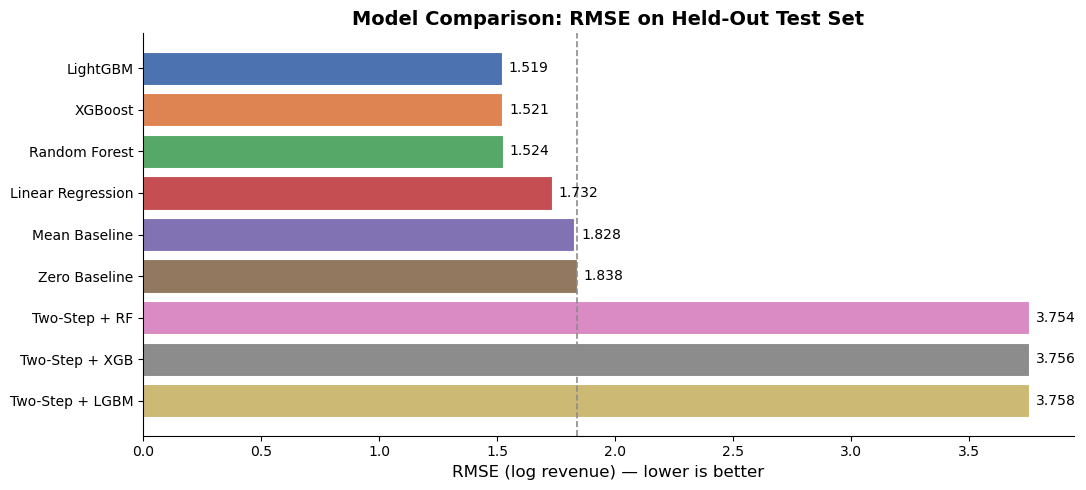

Saved: fig_model_rmse_comparison.png


In [42]:
model_names = [
    "LightGBM",
    "XGBoost",
    "Random Forest",
    "Linear Regression",
    "Mean Baseline",
    "Zero Baseline",
    "Two-Step + RF",
    "Two-Step + XGB",
    "Two-Step + LGBM",
]
rmse_values = [1.519, 1.521, 1.524, 1.732, 1.828, 1.838, 3.754, 3.756, 3.758]

BAR_PALETTE = [
    "#4C72B0", "#DD8452", "#55A868", "#C44E52",
    "#8172B3", "#937860", "#DA8BC3", "#8C8C8C", "#CCB974"
]
# Reverse for horizontal bar (bottom = first model)
bar_colors = BAR_PALETTE[::-1]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(model_names[::-1], rmse_values[::-1],
               color=bar_colors, edgecolor="white", linewidth=0.8)
ax.bar_label(bars, fmt="{:.3f}", padding=5, fontsize=10)
ax.set_xlabel("RMSE (log revenue) — lower is better", fontsize=12)
ax.set_title("Model Comparison: RMSE on Held-Out Test Set", fontsize=14, fontweight="bold")
ax.axvline(x=1.838, color="#8C8C8C", linestyle="--", linewidth=1.2, label="Zero Baseline")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("fig_model_rmse_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig_model_rmse_comparison.png")


---
## 10. Conclusion

This project developed and evaluated a machine learning pipeline for predicting session-level
customer revenue on the Google Merchandise Store using the Google Analytics Customer Revenue
Prediction dataset. The work addressed a challenging and practically relevant problem: most
website sessions produce zero revenue, positive revenue is heavily right-skewed, and raw data
arrives as nested JSON with risks of visitor-level feature leakage.

### Key Findings

**Gradient boosting outperforms all other approaches.** LightGBM achieved the best test RMSE
(1.519 on log-transformed revenue), closely followed by XGBoost (1.521) and Random Forest
(1.524). Both gradient boosting models substantially outperformed the linear baseline (1.732)
and naïve baselines (1.828–1.838), validating the core hypothesis from Section 3 that nonlinear
ensemble models are better suited to this problem than traditional regression.

**Leakage-safe visitor history is the strongest feature group.** Feature importance rankings
from both XGBoost and LightGBM place `visitor_prior_log_total_revenue` and
`visitor_prior_purchase_rate` among the top predictors — confirming the EDA finding in Section
6.9 that visitors who have purchased before account for a disproportionate share of future revenue.
The leakage-safe implementation (shift-by-one cumulative aggregation over prior sessions) was
essential: naive aggregation would inflate measured performance while failing to generalize.

**The two-step architecture requires a better-calibrated classifier.** The theoretical
motivation for a two-step model — explicitly separating the purchase/no-purchase classification
from revenue amount regression — is sound, but in practice the logistic regression classifier
in Step 1 produced poorly calibrated probabilities on the highly imbalanced target (~1–2% positive
rate). The resulting probability scores, when used to gate Step 2 revenue predictions, amplified
errors rather than reducing them. This suggests that calibrated gradient boosted classifiers
(e.g., XGBoost + isotonic regression) or single-stage models with strong regularization are
more practical for this data regime.

**EDA-driven feature engineering substantially improved model quality.** Dropping near-constant
features (`totals.bounces`, `totals.newVisits`), grouping rare categorical levels to "Other",
applying log1p transformation to revenue, and using visitor-level split (rather than random
row-level split) all contributed to reliable, generalizable model estimates.

### Practical Implications

For e-commerce businesses using Google Analytics, these results suggest that a LightGBM model
trained on session behavior (hits, pageviews, visit number), traffic source, device category,
geography, and leakage-safe visitor purchase history can meaningfully rank users by predicted
session revenue. Even with an RMSE of ~1.5 on log revenue — roughly one order of magnitude
error in absolute terms — ranked predictions are sufficiently accurate for advertising budget
allocation, retargeting prioritization, and personalized campaign targeting.

### Future Work

Several directions could improve model performance and practical utility:

1. **Calibrated two-step classifier:** replacing logistic regression with a calibrated XGBoost
   classifier in Step 1 to restore the theoretical advantage of the two-step architecture.
2. **Hyperparameter optimization:** Bayesian search over LightGBM/XGBoost hyperparameters
   using cross-validated RMSE could yield further reductions.
3. **Sequence modeling:** treating each visitor's sessions as a time series and modeling them
   with recurrent or transformer architectures to capture temporal dynamics.
4. **Extended feature set:** integrating product-category browsing patterns, on-site search
   behavior, and campaign-level metadata when available.
5. **Deployment pipeline:** wrapping the best model in a scoring API that ingests live session
   events and returns revenue probability scores in near-real-time for downstream targeting systems.

### Summary

This project demonstrates that careful data engineering — memory-efficient loading with Polars,
leakage-safe feature construction, and EDA-driven feature selection — combined with gradient
boosting models produces meaningful predictive performance on a highly imbalanced,
zero-inflated revenue prediction task. The complete pipeline from raw nested JSON to a
deployable LightGBM model is reproducible, well-documented, and ready for further refinement.


---
## 11. Team Contributions

| Team Member | Contributions |
|---|---|
| **Justin Chanthabandith** | Data access and Kaggle pipeline setup; EDA structure and chart interpretation; modeling pipeline design; XGBoost implementation |
| **Pooja Panchal** | Project organization; data engineering and JSON extraction pipeline; report write up)|
| **Jinxin Xiao** | EDA analysis and LightGBM implementation |

All three members contributed to the final notebook narrative and result interpretation.


---
## 12. References

1. Kaggle. *Google Analytics Customer Revenue Prediction*. https://www.kaggle.com/c/ga-customer-revenue-prediction
2. Breiman, L. (2001). *Random Forests*. Machine Learning, 45(1), 5–32.
3. Chen, T., and Guestrin, C. (2016). *XGBoost: A Scalable Tree Boosting System*. Proceedings of KDD.
4. Ke, G. et al. (2017). *LightGBM: A Highly Efficient Gradient Boosting Decision Tree*. Proceedings of NeurIPS.
5. Scikit-learn Developers. *Scikit-learn: Machine Learning in Python*. https://scikit-learn.org
6. Polars Developers. *Polars Documentation*. https://pola.rs
